D:\py\Anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
D:\py\Anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Loading data...
Engineering Features...
Training Standard LSTM Model (Ref: Liang Yuwan)...


【Standard LSTM Model Comparison Results (Test Set = Group 7)】
【Training Set (Groups 1-6)】 R²: 0.8226, RMSE: 1.82
【Testing Set (Group 7)】     R²: 0.7946, RMSE: 2.14
数据已汇总并保存至: 12.csv | 总行数: 243
Generating Model Comparison Charts (Group 7)...


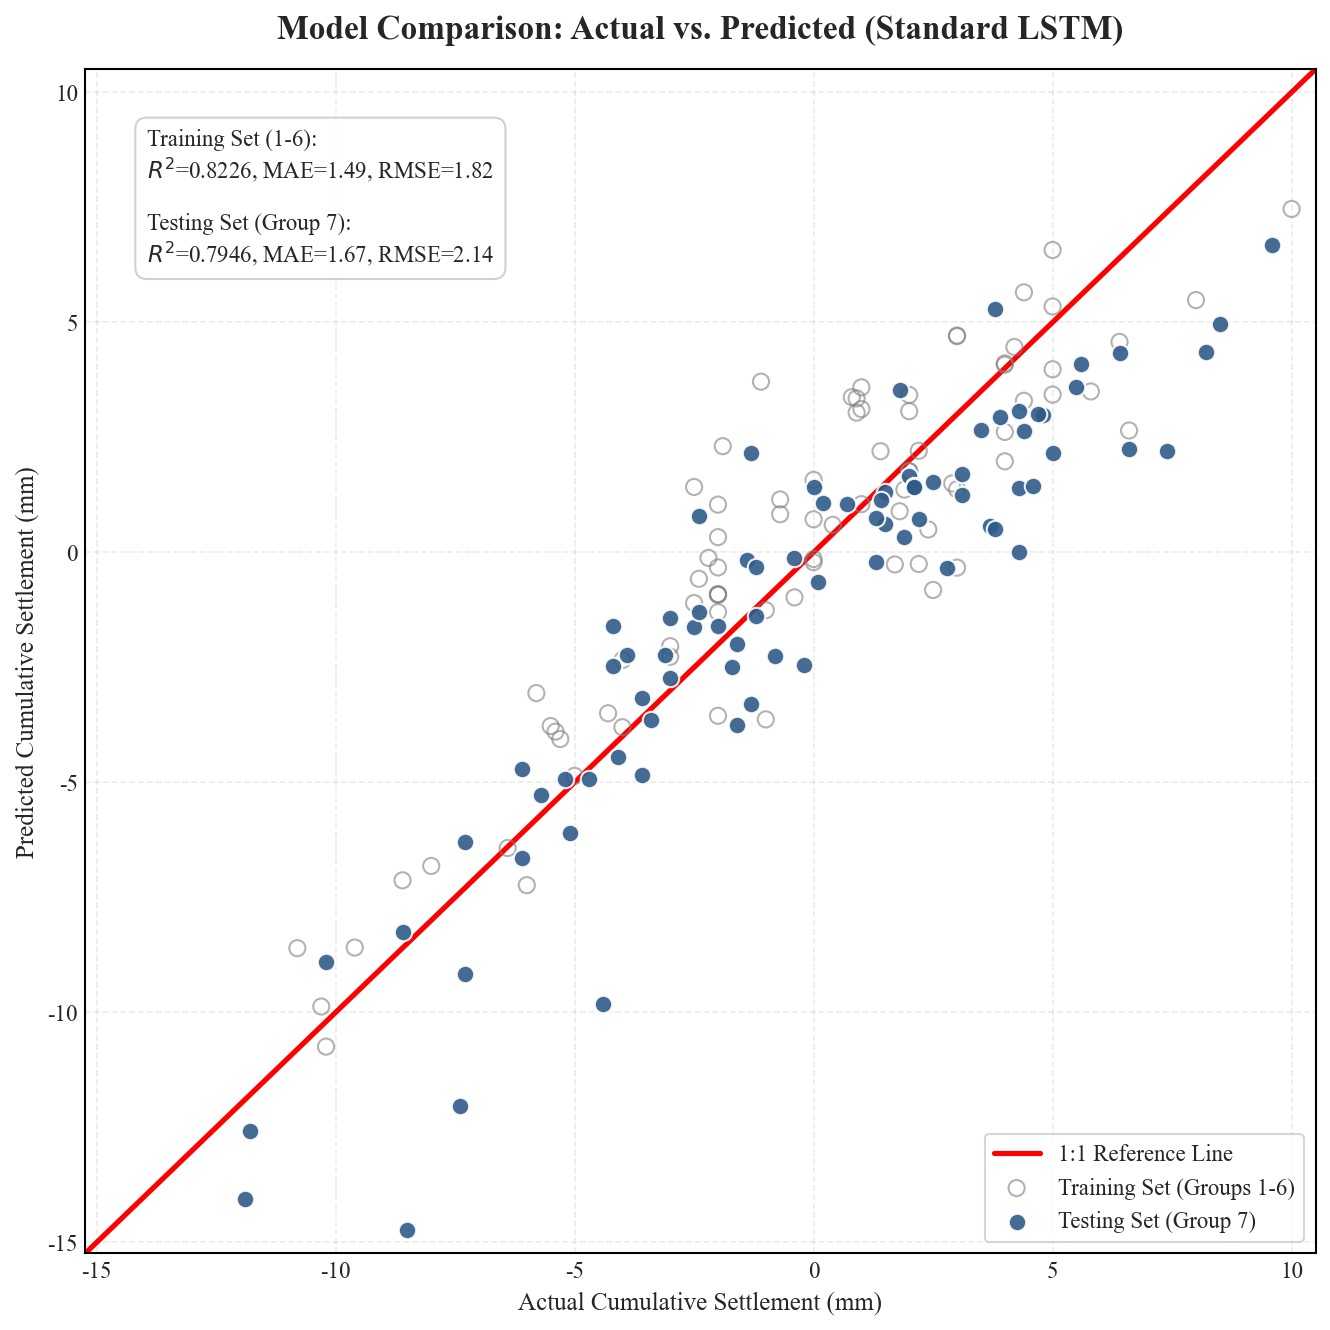

Standard LSTM Execution Complete! (Results saved to 12.csv)


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import warnings


# 0. 全局配置 
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('bmh')

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'obs': '#2E5B88', 'pred': '#D64045', 'res': '#6A4C93'
}

def set_seed(seed=2024):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(2024)


# 保存函数 
def universal_save_results(res_tr, res_te, res_va, model_code):
    """
    保存方法：
    1. 自动合并 6-1-1 划分的所有数据。
    2. 严格按原始索引排序（sort_index），确保点位顺序与原始 Excel 完全一致。
    """
    full_df = pd.concat([res_tr, res_te, res_va], axis=0)
    full_df = full_df.sort_index()
    
    output_df = pd.DataFrame({
        'Actual': full_df['Actual_Cum'], 
        'Pred': full_df['Pred_Cum']
    })
    
    file_name = f"{model_code}.csv" 
    output_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"数据已汇总并保存至: {file_name} | 总行数: {len(output_df)}")


# 1. 数据加载与预处理
file_path = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"
print("Loading data...")

try:
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    data_list = []
    for i, sheet in enumerate(all_sheets.values()):
        sheet.columns = [str(c).strip() for c in sheet.columns]
        col_map = {}
        for c in sheet.columns:
            if '编号' in c: col_map['ID'] = c
            elif '单次' in c: col_map['Single'] = c
            elif '速率' in c: col_map['Rate'] = c
            elif '累计' in c: col_map['Cumulative'] = c
        if len(col_map) >= 4:
            temp = sheet[[col_map['ID'], col_map['Single'], col_map['Rate'], col_map['Cumulative']]].copy()
            temp.columns = ['ID', 'Single', 'Rate', 'Cumulative']
            temp['TimeStep'] = i + 1
            data_list.append(temp)
    data = pd.concat(data_list).dropna().sort_values(['ID', 'TimeStep']).reset_index(drop=True)
except Exception as e:
    raise ValueError(f"无法读取数据，请检查路径: {e}")


# 2. 特征工程
print("Engineering Features...")
df = data.copy()

df['Roll_Mean'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).mean())
df['Roll_Std'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).std())
df['EMA_3'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
df['Diff_1'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - x.shift(2))
df['Diff_2'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - 2*x.shift(2) + x.shift(3))

df = df.fillna(method='bfill').fillna(0)

feature_cols = ['Single', 'Rate', 'Cumulative', 'Roll_Mean', 'Roll_Std', 'EMA_3', 'Diff_1', 'Diff_2']
target_col = 'Cumulative'


# 3. 序列生成与【严格 6-1-1 划分】
scaler = MinMaxScaler(feature_range=(-1, 1))

train_subset = df[df['TimeStep'] <= 6]
scaler.fit(train_subset[feature_cols])

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.transform(df[feature_cols])

def create_sequences(dataframe, look_back):
    X, y, times, indices = [], [], [], []
    target_idx = feature_cols.index(target_col)
    for _, group in dataframe.groupby('ID'):
        group = group.sort_values('TimeStep')
        vals = group[feature_cols].values
        ts = group['TimeStep'].values
        idx = group.index.values 
        
        if len(vals) > look_back:
            for i in range(len(vals) - look_back):
                X.append(vals[i:i+look_back])
                y.append(vals[i+look_back, target_idx])
                times.append(ts[i+look_back])
                indices.append(idx[i+look_back]) 
    return np.array(X), np.array(y), np.array(times), np.array(indices)

look_back = 5 
X, y, times, indices = create_sequences(df_scaled, look_back)

mask_train = times <= 6
mask_test  = times == 7
mask_val   = times == 8

X_train, y_train_scaled = X[mask_train], y[mask_train]
X_test, y_test_scaled   = X[mask_test], y[mask_test]   
X_val, y_val_scaled     = X[mask_val], y[mask_val]     


# 4. Standard LSTM 模型 (严格复刻梁煜婉文献思路)

def build_standard_lstm_model(input_shape):
    K.clear_session()
    model = Sequential()
    
    model.add(LSTM(128, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.1)) 
    
    model.add(LSTM(64, return_sequences=False))
    model.add(Dropout(0.1))
    
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
    model.compile(loss='mse', optimizer=optimizer)
    return model

print("Training Standard LSTM Model (Ref: Liang Yuwan)...")
model = build_standard_lstm_model((look_back, len(feature_cols)))

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train, y_train_scaled,
    epochs=150,
    batch_size=4,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=0
)


# 5. 预测、评估与保存
def inverse_transform_y(y_scaled, scaler, target_idx):
    dummy = np.zeros((len(y_scaled), len(feature_cols)))
    dummy[:, target_idx] = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

target_idx = feature_cols.index(target_col)

y_pred_train = inverse_transform_y(model.predict(X_train, verbose=0), scaler, target_idx)
y_true_train = inverse_transform_y(y_train_scaled, scaler, target_idx)

y_pred_test = inverse_transform_y(model.predict(X_test, verbose=0), scaler, target_idx)
y_true_test = inverse_transform_y(y_test_scaled, scaler, target_idx)
residuals_test = y_true_test - y_pred_test

y_pred_val = inverse_transform_y(model.predict(X_val, verbose=0), scaler, target_idx)
y_true_val = inverse_transform_y(y_val_scaled, scaler, target_idx)

train_r2 = r2_score(y_true_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
train_mae = mean_absolute_error(y_true_train, y_pred_train)

test_r2 = r2_score(y_true_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
test_mae = mean_absolute_error(y_true_test, y_pred_test)

print("\n" + "="*50)
print(f"【Standard LSTM Model Comparison Results (Test Set = Group 7)】")
print(f"【Training Set (Groups 1-6)】 R²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"【Testing Set (Group 7)】     R²: {test_r2:.4f}, RMSE: {test_rmse:.2f}")
print("="*50)

res_tr = pd.DataFrame({'Actual_Cum': y_true_train, 'Pred_Cum': y_pred_train}, index=indices[mask_train])
res_te = pd.DataFrame({'Actual_Cum': y_true_test, 'Pred_Cum': y_pred_test}, index=indices[mask_test])
res_va = pd.DataFrame({'Actual_Cum': y_true_val, 'Pred_Cum': y_pred_val}, index=indices[mask_val])

universal_save_results(res_tr, res_te, res_va, '12')


# 6. 模型对比专属绘图 (仅展示训练集和第7组)
print("Generating Model Comparison Charts (Group 7)...")

# --- Chart 1: 1:1 Regression Plot ---
plt.figure(figsize=(9, 9), dpi=150)
ax = plt.gca() 

limit_min = min(y_true_train.min(), y_pred_train.min(), y_true_test.min(), y_pred_test.min()) - 0.5
limit_max = max(y_true_train.max(), y_pred_train.max(), y_true_test.max(), y_pred_test.max()) + 0.5

plt.plot([limit_min, limit_max], [limit_min, limit_max], 'r-', linewidth=2.5, label='1:1 Reference Line', zorder=1)

plt.scatter(y_true_train, y_pred_train, facecolors='none', edgecolors='gray', 
            marker='o', s=60, alpha=0.6, label='Training Set (Groups 1-6)', zorder=2)
plt.scatter(y_true_test, y_pred_test, color=COLORS['obs'], edgecolor='white', 
            marker='o', s=70, alpha=0.9, label='Testing Set (Group 7)', zorder=3)

metrics_text = (
    f"Training Set (1-6):\n"
    f"$R^2$={train_r2:.4f}, MAE={train_mae:.2f}, RMSE={train_rmse:.2f}\n"
    f"\n"
    f"Testing Set (Group 7):\n"
    f"$R^2$={test_r2:.4f}, MAE={test_mae:.2f}, RMSE={test_rmse:.2f}"
)

plt.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=11, 
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'))

plt.xlabel('Actual Cumulative Settlement (mm)', fontsize=12)
plt.ylabel('Predicted Cumulative Settlement (mm)', fontsize=12)
plt.title('Model Comparison: Actual vs. Predicted (Standard LSTM)', fontweight='bold', fontsize=16, pad=15)

plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)

for spine_name in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine_name].set_visible(True)     
    ax.spines[spine_name].set_color('black')    
    ax.spines[spine_name].set_linewidth(1.0)    

plt.tight_layout()
plt.show()

print("Standard LSTM Execution Complete! (Results saved to 12.csv)")

Loading data...
Engineering Features...
Training GRU Model (Ref: Li Luobin)...

【GRU Model Comparison Results (Test Set = Group 7)】
【Training Set (Groups 1-6)】 R²: 0.8342, RMSE: 1.76
【Testing Set (Group 7)】     R²: 0.8379, RMSE: 1.90
数据已汇总并保存至: 13.csv | 总行数: 243
Generating Model Comparison Charts (Group 7)...


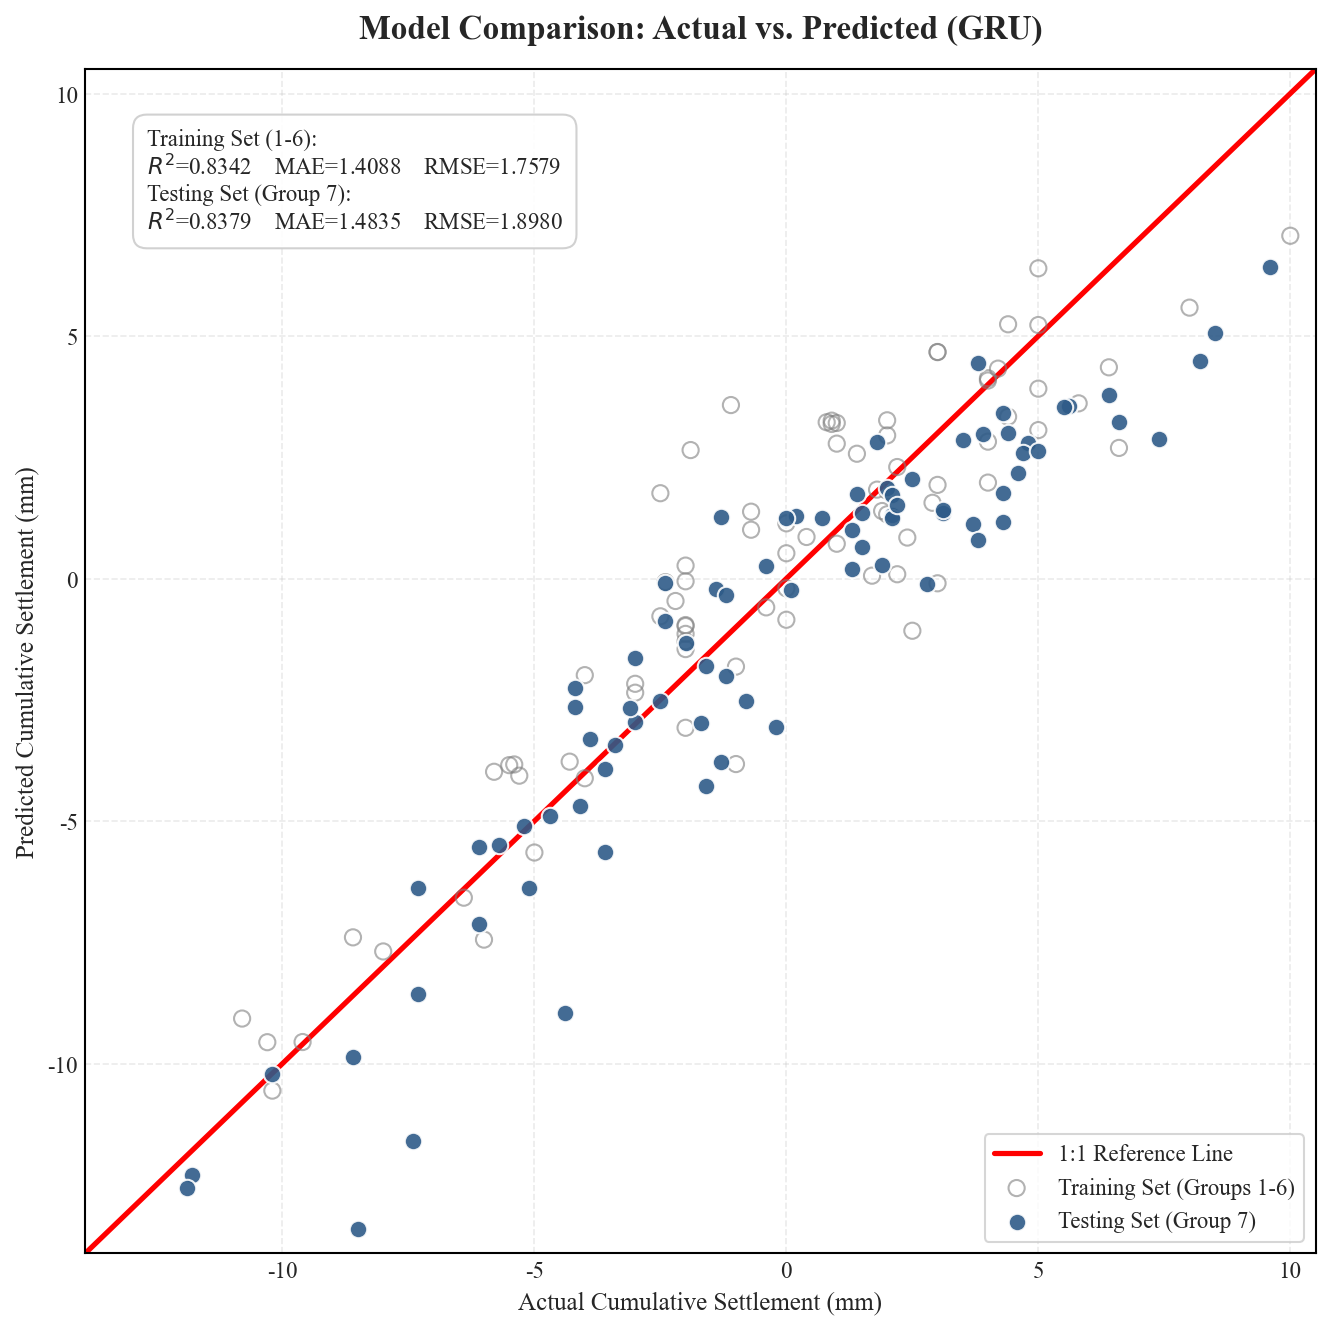

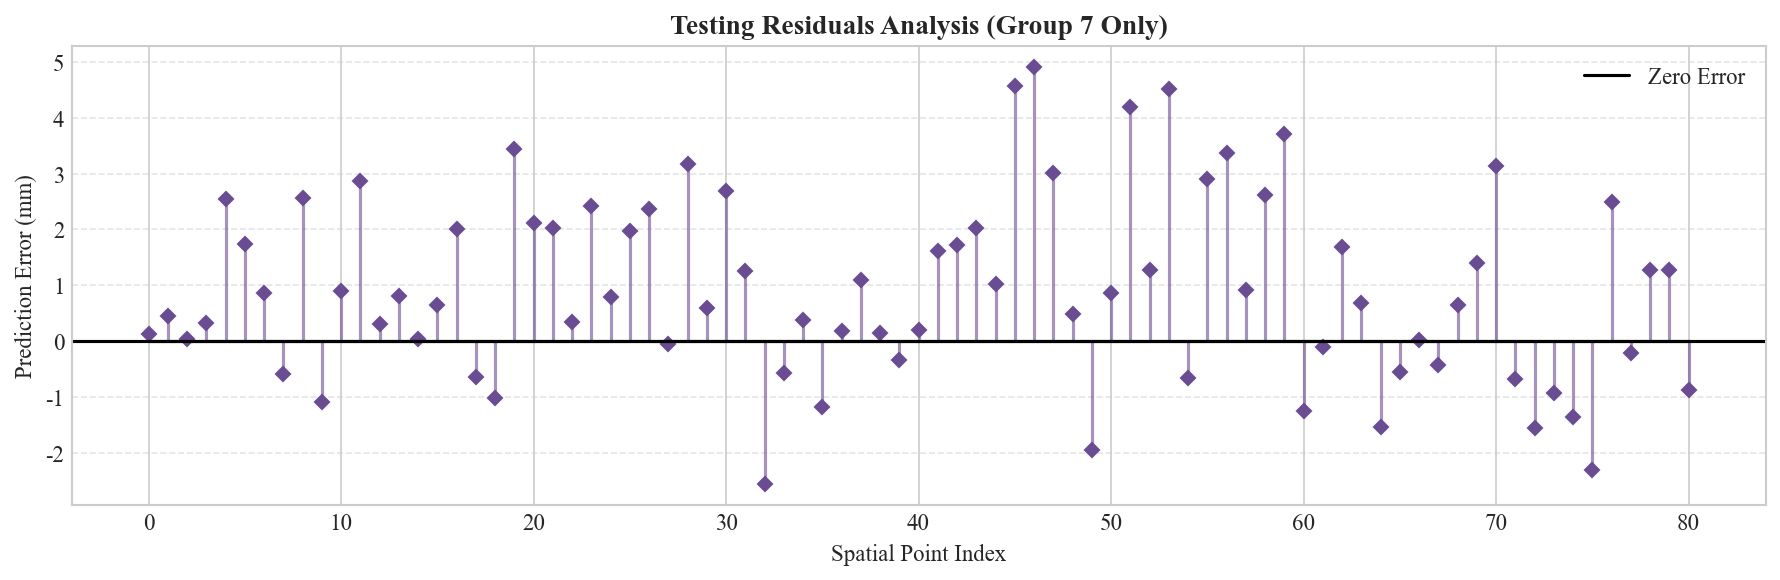

GRU Model Execution Complete! (Results saved to 13.csv)


In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import warnings


# 0. 全局配置 
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('bmh')

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'obs': '#2E5B88', 'pred': '#D64045', 'res': '#6A4C93'
}

def set_seed(seed=2024):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(2024)


# 保存函数 
def universal_save_results(res_tr, res_te, res_va, model_code):
    """
    保存方法：
    1. 自动合并 6-1-1 划分的所有数据。
    2. 严格按原始索引排序（sort_index），确保点位顺序与原始 Excel 完全一致。
    """
    full_df = pd.concat([res_tr, res_te, res_va], axis=0)
    full_df = full_df.sort_index()
    
    output_df = pd.DataFrame({
        'Actual': full_df['Actual_Cum'], 
        'Pred': full_df['Pred_Cum']
    })
    
    file_name = f"{model_code}.csv" 
    output_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"数据已汇总并保存至: {file_name} | 总行数: {len(output_df)}")


# 1. 数据加载与预处理
file_path = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"
print("Loading data...")

try:
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    data_list = []
    for i, sheet in enumerate(all_sheets.values()):
        sheet.columns = [str(c).strip() for c in sheet.columns]
        col_map = {}
        for c in sheet.columns:
            if '编号' in c: col_map['ID'] = c
            elif '单次' in c: col_map['Single'] = c
            elif '速率' in c: col_map['Rate'] = c
            elif '累计' in c: col_map['Cumulative'] = c
        if len(col_map) >= 4:
            temp = sheet[[col_map['ID'], col_map['Single'], col_map['Rate'], col_map['Cumulative']]].copy()
            temp.columns = ['ID', 'Single', 'Rate', 'Cumulative']
            temp['TimeStep'] = i + 1
            data_list.append(temp)
    data = pd.concat(data_list).dropna().sort_values(['ID', 'TimeStep']).reset_index(drop=True)
except Exception as e:
    raise ValueError(f"无法读取数据，请检查路径: {e}")


# 2. 特征工程
print("Engineering Features...")
df = data.copy()

df['Roll_Mean'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).mean())
df['Roll_Std'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).std())
df['EMA_3'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
df['Diff_1'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - x.shift(2))
df['Diff_2'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - 2*x.shift(2) + x.shift(3))

df = df.fillna(method='bfill').fillna(0)

feature_cols = ['Single', 'Rate', 'Cumulative', 'Roll_Mean', 'Roll_Std', 'EMA_3', 'Diff_1', 'Diff_2']
target_col = 'Cumulative'


# 3. 序列生成与【严格 6-1-1 划分】
scaler = MinMaxScaler(feature_range=(-1, 1))

train_subset = df[df['TimeStep'] <= 6]
scaler.fit(train_subset[feature_cols])

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.transform(df[feature_cols])

def create_sequences(dataframe, look_back):
    X, y, times, indices = [], [], [], []
    target_idx = feature_cols.index(target_col)
    for _, group in dataframe.groupby('ID'):
        group = group.sort_values('TimeStep')
        vals = group[feature_cols].values
        ts = group['TimeStep'].values
        idx = group.index.values 
        
        if len(vals) > look_back:
            for i in range(len(vals) - look_back):
                X.append(vals[i:i+look_back])
                y.append(vals[i+look_back, target_idx])
                times.append(ts[i+look_back])
                indices.append(idx[i+look_back]) 
    return np.array(X), np.array(y), np.array(times), np.array(indices)

look_back = 5 
X, y, times, indices = create_sequences(df_scaled, look_back)

mask_train = times <= 6
mask_test  = times == 7
mask_val   = times == 8

X_train, y_train_scaled = X[mask_train], y[mask_train]
X_test, y_test_scaled   = X[mask_test], y[mask_test]   
X_val, y_val_scaled     = X[mask_val], y[mask_val]     


# 4. GRU 模型 (严格复刻李洛宾文献思路)
def build_gru_model(input_shape):
    K.clear_session()
    model = Sequential()
    
    model.add(GRU(128, return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.1)) 
    
    model.add(GRU(64, return_sequences=False))
    model.add(Dropout(0.1))

    model.add(Dense(32, activation='relu'))
    
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
    model.compile(loss='mse', optimizer=optimizer)
    return model

print("Training GRU Model (Ref: Li Luobin)...")
model = build_gru_model((look_back, len(feature_cols)))

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train, y_train_scaled,
    epochs=150,
    batch_size=4,
    validation_split=0.15,
    callbacks=[early_stop],
    verbose=0
)


# 5. 预测、评估与保存
def inverse_transform_y(y_scaled, scaler, target_idx):
    dummy = np.zeros((len(y_scaled), len(feature_cols)))
    dummy[:, target_idx] = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

target_idx = feature_cols.index(target_col)

y_pred_train = inverse_transform_y(model.predict(X_train, verbose=0), scaler, target_idx)
y_true_train = inverse_transform_y(y_train_scaled, scaler, target_idx)

y_pred_test = inverse_transform_y(model.predict(X_test, verbose=0), scaler, target_idx)
y_true_test = inverse_transform_y(y_test_scaled, scaler, target_idx)
residuals_test = y_true_test - y_pred_test

y_pred_val = inverse_transform_y(model.predict(X_val, verbose=0), scaler, target_idx)
y_true_val = inverse_transform_y(y_val_scaled, scaler, target_idx)

train_r2 = r2_score(y_true_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
train_mae = mean_absolute_error(y_true_train, y_pred_train)

test_r2 = r2_score(y_true_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
test_mae = mean_absolute_error(y_true_test, y_pred_test)

print("\n" + "="*50)
print(f"【GRU Model Comparison Results (Test Set = Group 7)】")
print(f"【Training Set (Groups 1-6)】 R²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"【Testing Set (Group 7)】     R²: {test_r2:.4f}, RMSE: {test_rmse:.2f}")
print("="*50)

res_tr = pd.DataFrame({'Actual_Cum': y_true_train, 'Pred_Cum': y_pred_train}, index=indices[mask_train])
res_te = pd.DataFrame({'Actual_Cum': y_true_test, 'Pred_Cum': y_pred_test}, index=indices[mask_test])
res_va = pd.DataFrame({'Actual_Cum': y_true_val, 'Pred_Cum': y_pred_val}, index=indices[mask_val])

universal_save_results(res_tr, res_te, res_va, '13')


# 6. 模型对比专属绘图 (仅展示训练集和第7组)
print("Generating Model Comparison Charts (Group 7)...")

# --- Chart 1: 1:1 Regression Plot ---
plt.figure(figsize=(9, 9), dpi=150)
ax = plt.gca() 

limit_min = min(y_true_train.min(), y_pred_train.min(), y_true_test.min(), y_pred_test.min()) - 0.5
limit_max = max(y_true_train.max(), y_pred_train.max(), y_true_test.max(), y_pred_test.max()) + 0.5

plt.plot([limit_min, limit_max], [limit_min, limit_max], 'r-', linewidth=2.5, label='1:1 Reference Line', zorder=1)

plt.scatter(y_true_train, y_pred_train, facecolors='none', edgecolors='gray', 
            marker='o', s=60, alpha=0.6, label='Training Set (Groups 1-6)', zorder=2)
plt.scatter(y_true_test, y_pred_test, color=COLORS['obs'], edgecolor='white', 
            marker='o', s=70, alpha=0.9, label='Testing Set (Group 7)', zorder=3)

metrics_text = (
    f"Training Set (1-6):\n"
    f"$R^2$={train_r2:.4f}    MAE={train_mae:.4f}    RMSE={train_rmse:.4f}\n"
    f"Testing Set (Group 7):\n"
    f"$R^2$={test_r2:.4f}    MAE={test_mae:.4f}    RMSE={test_rmse:.4f}"
)

plt.text(0.05, 0.95, metrics_text, transform=ax.transAxes, fontsize=11, 
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'))

plt.xlabel('Actual Cumulative Settlement (mm)', fontsize=12)
plt.ylabel('Predicted Cumulative Settlement (mm)', fontsize=12)
plt.title('Model Comparison: Actual vs. Predicted (GRU)', fontweight='bold', fontsize=16, pad=15)

plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)

for spine_name in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine_name].set_visible(True)     
    ax.spines[spine_name].set_color('black')    
    ax.spines[spine_name].set_linewidth(1.0)    

plt.tight_layout()
plt.show()

# --- Chart 2: Residual Analysis (仅展示测试集第 7 组) ---
plt.figure(figsize=(12, 4), dpi=150)
x_axis = range(len(y_true_test))
plt.stem(x_axis, residuals_test, linefmt=COLORS['res'], markerfmt='D', basefmt='k-')
plt.setp(plt.gca().get_children()[0], linewidth=1.5, alpha=0.6)
plt.setp(plt.gca().get_children()[1], markersize=5, color=COLORS['res'])
plt.axhline(0, color='black', linestyle='-', linewidth=1.5)

plt.title('Testing Residuals Analysis (Group 7 Only)', fontweight='bold')
plt.xlabel('Spatial Point Index')
plt.ylabel('Prediction Error (mm)')
plt.legend(['Zero Error'], loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("GRU Model Execution Complete! (Results saved to 13.csv)")

Loading data...
Engineering Features...
Training BPNN (HN=81, Activation=Sigmoid, Ref: Huang Liangyu)...

【BPNN Model Comparison Results (Test Set = Group 7)】
【Training Set (Groups 1-6)】 R²: 0.8150, RMSE: 1.86
【Testing Set (Group 7)】     R²: 0.8676, RMSE: 1.72
数据已汇总并保存至: 14.csv | 总行数: 243
Generating Model Comparison Charts (Group 7)...


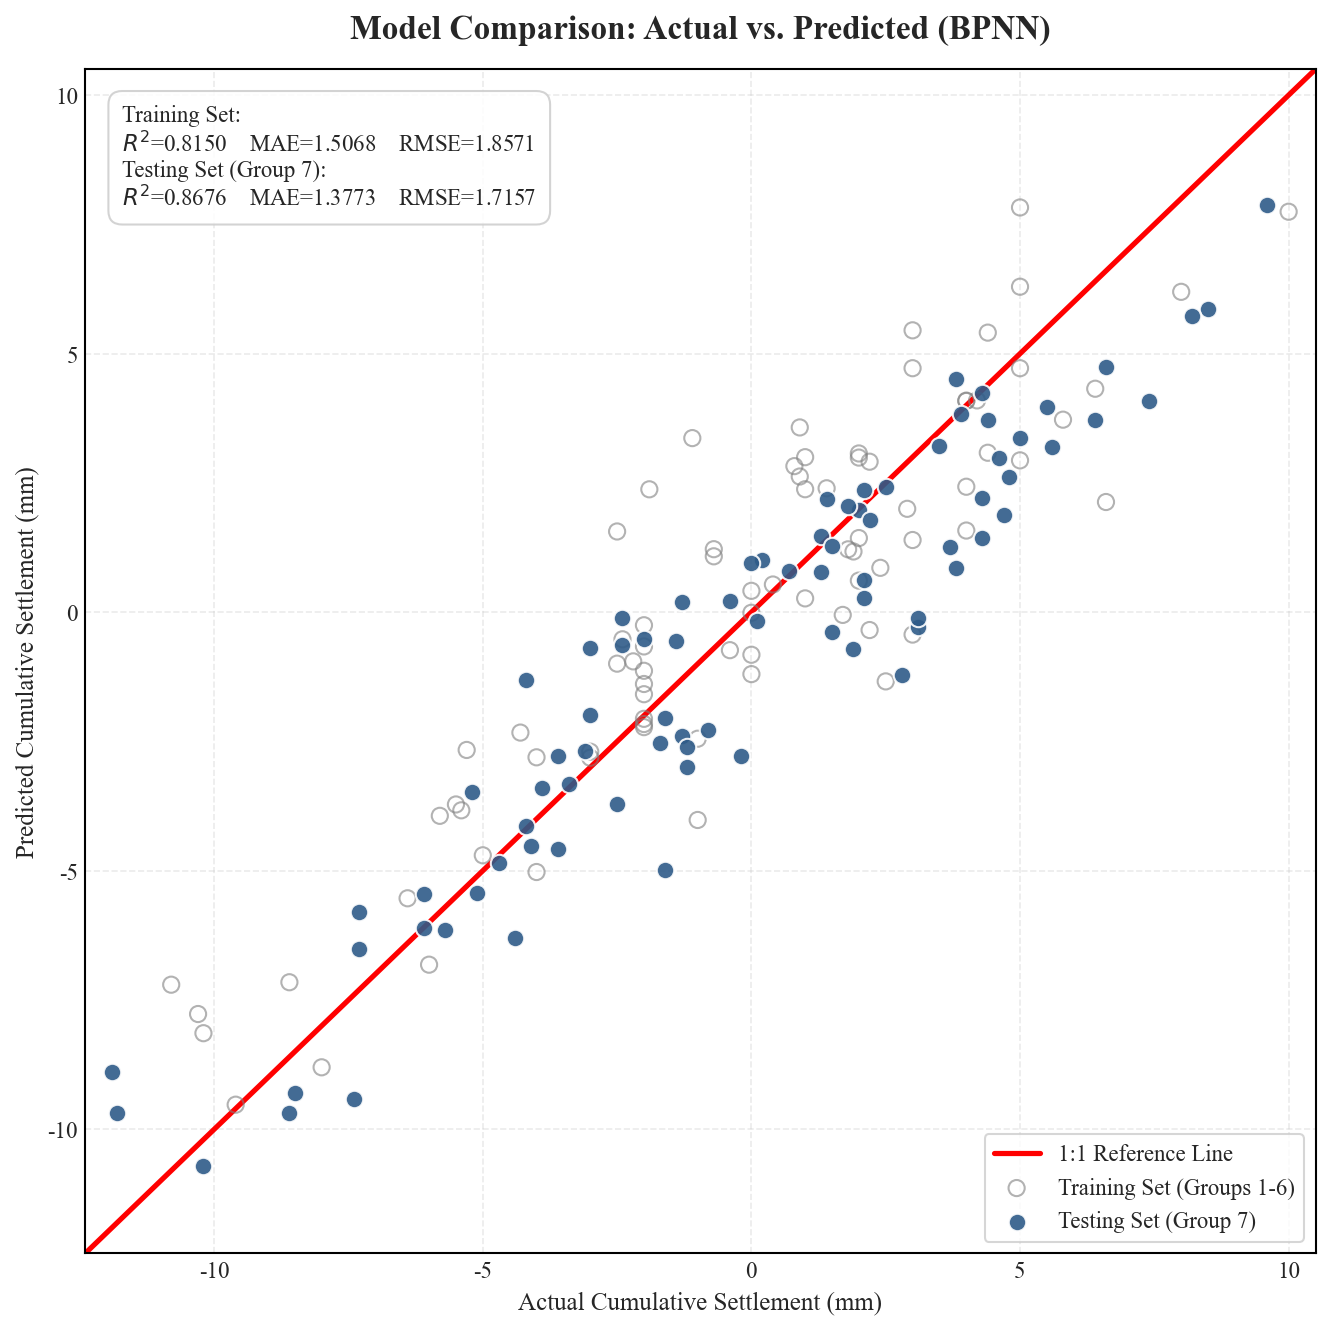

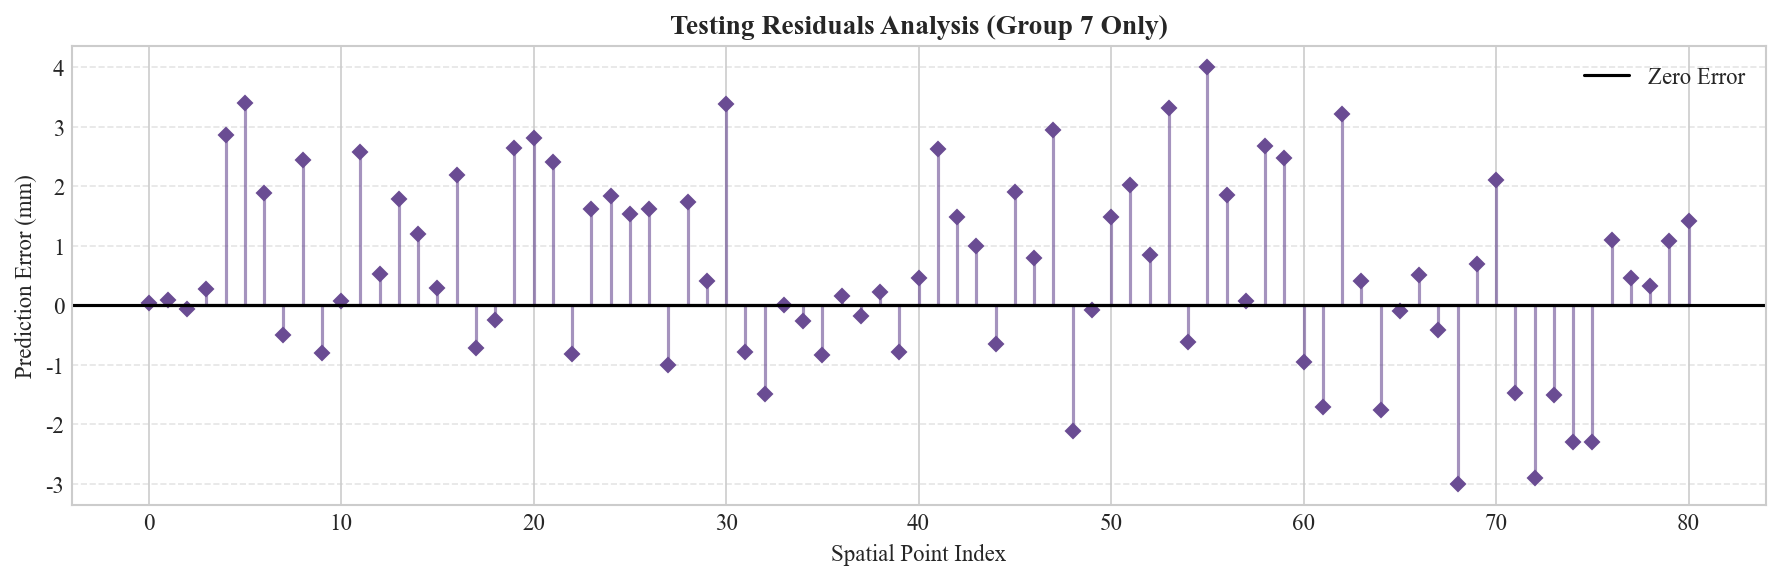

BPNN Execution Complete! (Results saved to 14.csv)


In [3]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, InputLayer
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import warnings


# 0. 全局配置
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('bmh')

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'obs': '#2E5B88', 'pred': '#D64045', 'res': '#6A4C93'
}

def set_seed(seed=2024):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(2024)


# 保存函数 

def universal_save_results(res_tr, res_te, res_va, model_code):
    """
    保存方法：
    1. 自动合并 6-1-1 划分的所有数据。
    2. 严格按原始索引排序（sort_index），确保 648 个点位顺序与原始 Excel 完全一致。
    """
    full_df = pd.concat([res_tr, res_te, res_va], axis=0)
    full_df = full_df.sort_index()
    
    output_df = pd.DataFrame({
        'Actual': full_df['Actual_Cum'], 
        'Pred': full_df['Pred_Cum']
    })
    
    file_name = f"{model_code}.csv" 
    output_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"数据已汇总并保存至: {file_name} | 总行数: {len(output_df)}")


# 1. 数据加载与预处理
file_path = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"
print("Loading data...")

try:
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    data_list = []
    for i, sheet in enumerate(all_sheets.values()):
        sheet.columns = [str(c).strip() for c in sheet.columns]
        col_map = {}
        for c in sheet.columns:
            if '编号' in c: col_map['ID'] = c
            elif '单次' in c: col_map['Single'] = c
            elif '速率' in c: col_map['Rate'] = c
            elif '累计' in c: col_map['Cumulative'] = c
        if len(col_map) >= 4:
            temp = sheet[[col_map['ID'], col_map['Single'], col_map['Rate'], col_map['Cumulative']]].copy()
            temp.columns = ['ID', 'Single', 'Rate', 'Cumulative']
            temp['TimeStep'] = i + 1
            data_list.append(temp)
    data = pd.concat(data_list).dropna().sort_values(['ID', 'TimeStep']).reset_index(drop=True)
except Exception as e:
    raise ValueError(f"无法读取数据，请检查路径: {e}")


# 2. 特征工程
print("Engineering Features...")
df = data.copy()

df['Roll_Mean'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).mean())
df['Roll_Std'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).std())
df['EMA_3'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
df['Diff_1'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - x.shift(2))
df['Diff_2'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - 2*x.shift(2) + x.shift(3))

df = df.fillna(method='bfill').fillna(0)

feature_cols = ['Single', 'Rate', 'Cumulative', 'Roll_Mean', 'Roll_Std', 'EMA_3', 'Diff_1', 'Diff_2']
target_col = 'Cumulative'


# 3. 序列生成与【严格 6-1-1 划分】
scaler = MinMaxScaler(feature_range=(-1, 1))

train_subset = df[df['TimeStep'] <= 6]
scaler.fit(train_subset[feature_cols])

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.transform(df[feature_cols])

def create_sequences(dataframe, look_back):
    X, y, times, indices = [], [], [], []
    target_idx = feature_cols.index(target_col)
    for _, group in dataframe.groupby('ID'):
        group = group.sort_values('TimeStep')
        vals = group[feature_cols].values
        ts = group['TimeStep'].values
        idx = group.index.values
        
        if len(vals) > look_back:
            for i in range(len(vals) - look_back):
                X.append(vals[i:i+look_back])
                y.append(vals[i+look_back, target_idx])
                times.append(ts[i+look_back])
                indices.append(idx[i+look_back]) 
    return np.array(X), np.array(y), np.array(times), np.array(indices)

look_back = 5 
X, y, times, indices = create_sequences(df_scaled, look_back)

mask_train = times <= 6
mask_test  = times == 7
mask_val   = times == 8

X_train, y_train_scaled = X[mask_train], y[mask_train]
X_test, y_test_scaled   = X[mask_test], y[mask_test]   
X_val, y_val_scaled     = X[mask_val], y[mask_val]     

input_dim = X_train.shape[1] * X_train.shape[2]
X_train_flat = X_train.reshape((X_train.shape[0], input_dim))
X_test_flat = X_test.reshape((X_test.shape[0], input_dim))
X_val_flat = X_val.reshape((X_val.shape[0], input_dim)) 


# 4.BPNN 模型 (严格复刻黄靓钰文献思路)
def build_bp_model(input_dim):
    K.clear_session()
    model = Sequential()
    model.add(InputLayer(input_shape=(input_dim,)))
    
    hidden_nodes = 2 * input_dim + 1
    model.add(Dense(hidden_nodes, activation='sigmoid'))
    model.add(Dense(1, activation='linear'))
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
    model.compile(loss='mse', optimizer=optimizer)
    return model

print(f"Training BPNN (HN={2*input_dim+1}, Activation=Sigmoid, Ref: Huang Liangyu)...")
model = build_bp_model(input_dim)

early_stop = EarlyStopping(monitor='val_loss', patience=50, restore_best_weights=True)

history = model.fit(
    X_train_flat, y_train_scaled,
    epochs=2000, 
    batch_size=8,
    validation_split=0.15, 
    callbacks=[early_stop],
    verbose=0
)


# 5. 预测与评估
def inverse_transform_y(y_scaled, scaler, target_idx):
    dummy = np.zeros((len(y_scaled), len(feature_cols)))
    dummy[:, target_idx] = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

target_idx = feature_cols.index(target_col)

y_pred_train = inverse_transform_y(model.predict(X_train_flat, verbose=0), scaler, target_idx)
y_true_train = inverse_transform_y(y_train_scaled, scaler, target_idx)

y_pred_test = inverse_transform_y(model.predict(X_test_flat, verbose=0), scaler, target_idx)
y_true_test = inverse_transform_y(y_test_scaled, scaler, target_idx)
residuals_test = y_true_test - y_pred_test

y_pred_val = inverse_transform_y(model.predict(X_val_flat, verbose=0), scaler, target_idx)
y_true_val = inverse_transform_y(y_val_scaled, scaler, target_idx)

train_r2 = r2_score(y_true_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
train_mae = mean_absolute_error(y_true_train, y_pred_train)

test_r2 = r2_score(y_true_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_true_test, y_pred_test))
test_mae = mean_absolute_error(y_true_test, y_pred_test)

print("\n" + "="*50)
print(f"【BPNN Model Comparison Results (Test Set = Group 7)】")
print(f"【Training Set (Groups 1-6)】 R²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"【Testing Set (Group 7)】     R²: {test_r2:.4f}, RMSE: {test_rmse:.2f}")
print("="*50)

res_tr = pd.DataFrame({'Actual_Cum': y_true_train, 'Pred_Cum': y_pred_train}, index=indices[mask_train])
res_te = pd.DataFrame({'Actual_Cum': y_true_test, 'Pred_Cum': y_pred_test}, index=indices[mask_test])
res_va = pd.DataFrame({'Actual_Cum': y_true_val, 'Pred_Cum': y_pred_val}, index=indices[mask_val])

universal_save_results(res_tr, res_te, res_va, '14')


# 6. 模型对比专属绘图
print("Generating Model Comparison Charts (Group 7)...")

# --- Chart 1: 1:1 Regression Plot ---
plt.figure(figsize=(9, 9), dpi=150)
ax = plt.gca() 

limit_min = min(y_true_train.min(), y_pred_train.min(), y_true_test.min(), y_pred_test.min()) - 0.5
limit_max = max(y_true_train.max(), y_pred_train.max(), y_true_test.max(), y_pred_test.max()) + 0.5

plt.plot([limit_min, limit_max], [limit_min, limit_max], 'r-', linewidth=2.5, label='1:1 Reference Line', zorder=1)

plt.scatter(y_true_train, y_pred_train, facecolors='none', edgecolors='gray', 
            marker='o', s=60, alpha=0.6, label='Training Set (Groups 1-6)', zorder=2)
plt.scatter(y_true_test, y_pred_test, color=COLORS['obs'], edgecolor='white', 
            marker='o', s=70, alpha=0.9, label='Testing Set (Group 7)', zorder=3)

line1 = "Training Set:"
line2 = f"$R^2$={train_r2:.4f}    MAE={train_mae:.4f}    RMSE={train_rmse:.4f}"
line3 = "Testing Set (Group 7):"
line4 = f"$R^2$={test_r2:.4f}    MAE={test_mae:.4f}    RMSE={test_rmse:.4f}"

full_info = f"{line1}\n{line2}\n{line3}\n{line4}"

plt.text(0.03, 0.97, full_info, transform=ax.transAxes, fontsize=11, verticalalignment='top',
         family='Times New Roman', bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.85, edgecolor='#CCCCCC'))

plt.xlabel('Actual Cumulative Settlement (mm)', fontsize=12)
plt.ylabel('Predicted Cumulative Settlement (mm)', fontsize=12)
plt.title('Model Comparison: Actual vs. Predicted (BPNN)', fontweight='bold', fontsize=16, pad=15)

plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)

for spine_name in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine_name].set_visible(True)     
    ax.spines[spine_name].set_color('black')    
    ax.spines[spine_name].set_linewidth(1.0)    

plt.tight_layout()
plt.show()

# --- Chart 2: Residual Analysis (仅展示测试集第 7 组) ---
plt.figure(figsize=(12, 4), dpi=150)
x_axis = range(len(y_true_test))
plt.stem(x_axis, residuals_test, linefmt=COLORS['res'], markerfmt='D', basefmt='k-')
plt.setp(plt.gca().get_children()[0], linewidth=1.5, alpha=0.6)
plt.setp(plt.gca().get_children()[1], markersize=5, color=COLORS['res'])
plt.axhline(0, color='black', linestyle='-', linewidth=1.5)

plt.title('Testing Residuals Analysis (Group 7 Only)', fontweight='bold')
plt.xlabel('Spatial Point Index')
plt.ylabel('Prediction Error (mm)')
plt.legend(['Zero Error'], loc='upper right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("BPNN Execution Complete! (Results saved to 14.csv)")

 [Step 1] Loading Data & Training Models...

基于第 7 组数据的最优权重计算完成: w_GM=0.2506, w_BP=0.7494

数据已汇总并保存至: 15.csv | 总行数: 567


[Step 2] Generating Plots (Combined Model Engineering Validation)...

Generating Engineering Validation Charts for: Optimal Weight BP-GM ...


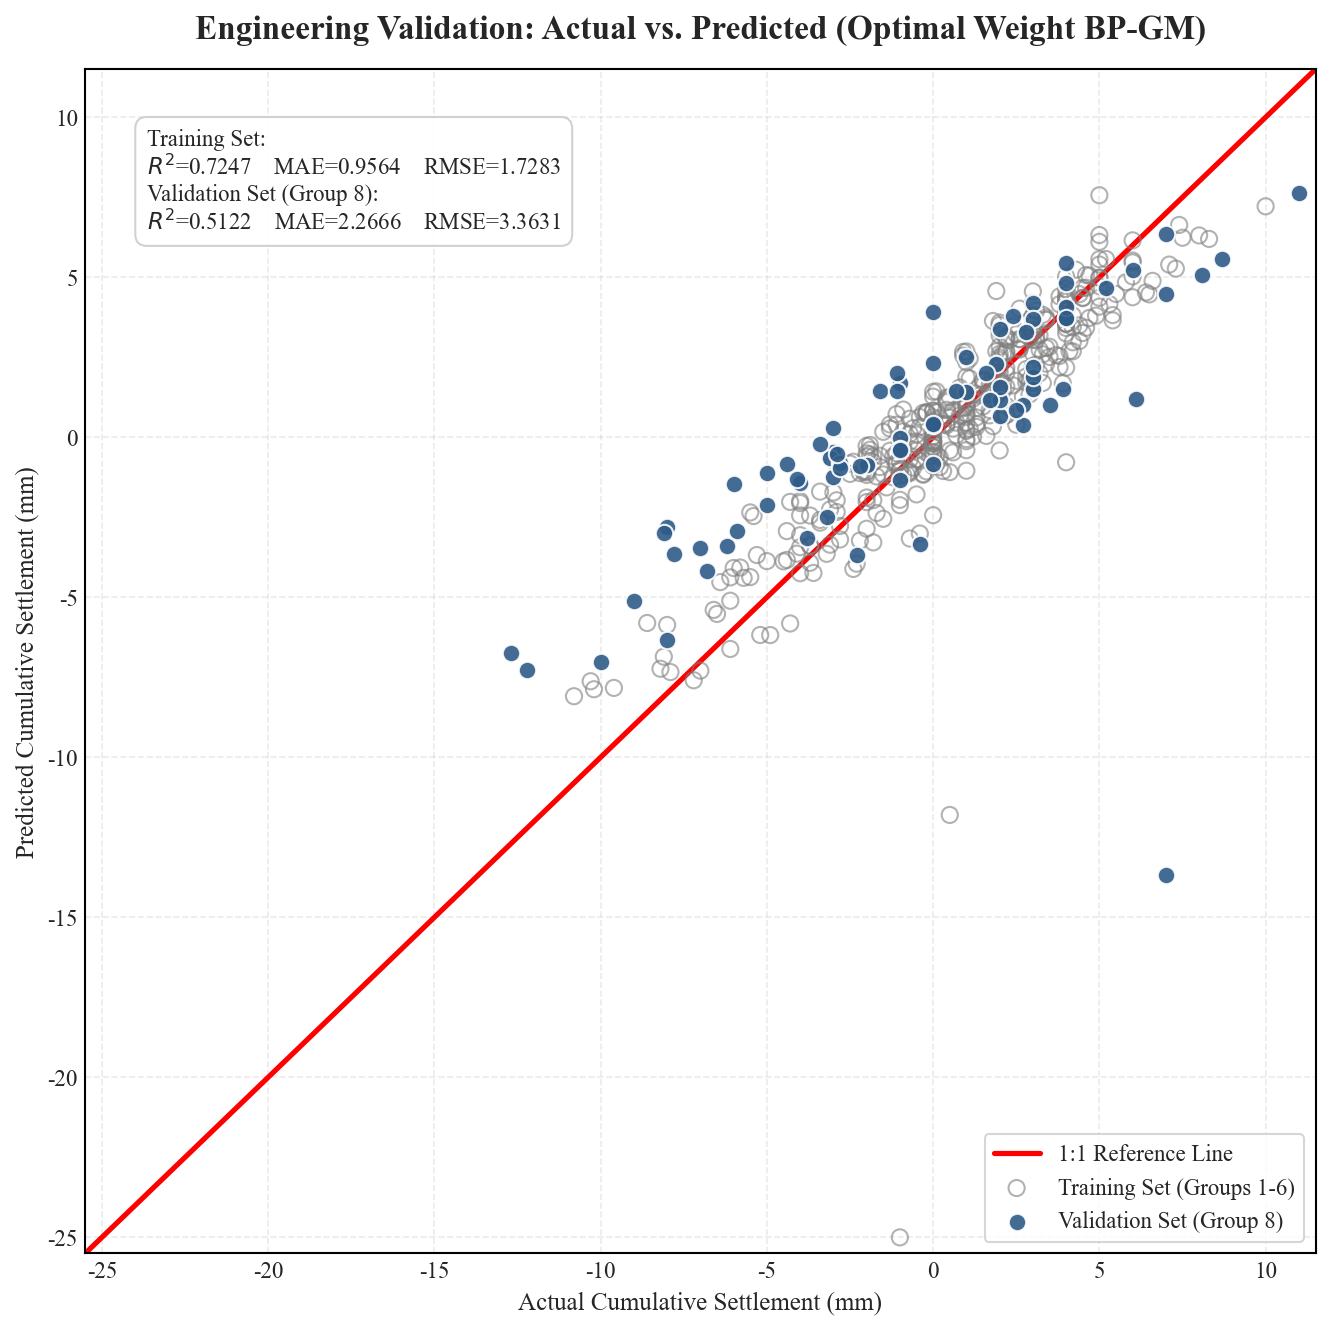

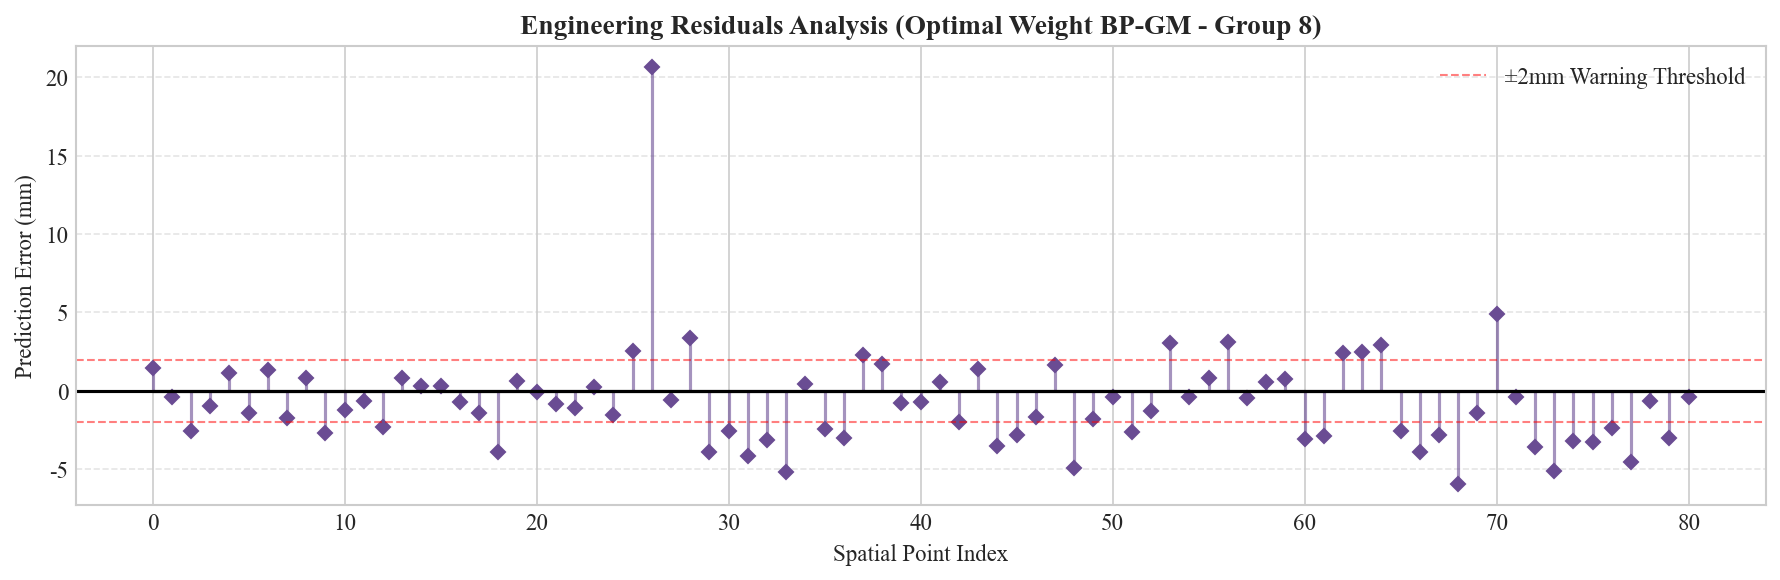


BP-GM Execution Complete! (Results saved to 15.csv)


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import os


# 0. 全局配置 
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('bmh')

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'obs': '#2E5B88', 'pred': '#D64045', 'res': '#6A4C93'
}

FILE_PATH = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"


# 保存函数
def universal_save_results(res_tr, res_te, res_va, model_code):
    """
    保存方法：
    由于 BP-GM 前面几步(窗口期)无法组合预测，
    为了对齐 648 行全量数据，对于前 3 步缺失的预测值，
    用真实值填充（或也可以留空，视对比需求），确保最终 index 完全对齐。
用真实值填充（或也可以留空，视对比需求），确保最终 index 完全对齐。
    """
    full_df = pd.concat([res_tr, res_te, res_va], axis=0)
    full_df = full_df.sort_index()
    
    output_df = pd.DataFrame({
        'Actual': full_df['Actual_Cum'], 
        'Pred': full_df['Pred_Cum']
    })
    
    file_name = f"{model_code}.csv" 
    output_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"\n数据已汇总并保存至: {file_name} | 总行数: {len(output_df)}\n")


# 1. 核心绘图引擎 
def plot_model_results(y_true_train, y_pred_train, y_true_eval, y_pred_eval, model_name):
    print(f"\nGenerating Engineering Validation Charts for: {model_name} ...")
    
    def get_metrics(true, pred):
        return (r2_score(true, pred), 
                mean_absolute_error(true, pred), 
                np.sqrt(mean_squared_error(true, pred)))

    r2_tr, mae_tr, rmse_tr = get_metrics(y_true_train, y_pred_train)
    r2_ev, mae_ev, rmse_ev = get_metrics(y_true_eval, y_pred_eval)
    residuals_eval = y_true_eval - y_pred_eval
    
  
    # Chart 1: 1:1 Regression Plot
    # ---------------------------------------------------
    plt.figure(figsize=(9, 9), dpi=150)
    ax = plt.gca()

    all_true = np.concatenate([y_true_train, y_true_eval])
    all_pred = np.concatenate([y_pred_train, y_pred_eval])
    limit_min = min(all_true.min(), all_pred.min()) - 0.5
    limit_max = max(all_true.max(), all_pred.max()) + 0.5

    plt.plot([limit_min, limit_max], [limit_min, limit_max], 'r-', linewidth=2.5, label='1:1 Reference Line', zorder=1)

    plt.scatter(y_true_train, y_pred_train, facecolors='none', edgecolors='gray', 
                marker='o', s=60, alpha=0.6, label='Training Set (Groups 1-6)', zorder=2)
    plt.scatter(y_true_eval, y_pred_eval, color=COLORS['obs'], edgecolor='white', 
                marker='o', s=70, alpha=0.9, label='Validation Set (Group 8)', zorder=3)

    line1 = "Training Set:"
    line2 = f"$R^2$={r2_tr:.4f}    MAE={mae_tr:.4f}    RMSE={rmse_tr:.4f}"
    line3 = "Validation Set (Group 8):"
    line4 = f"$R^2$={r2_ev:.4f}    MAE={mae_ev:.4f}    RMSE={rmse_ev:.4f}"
    
    full_info = f"{line1}\n{line2}\n{line3}\n{line4}"

    plt.text(0.05, 0.95, full_info, transform=ax.transAxes, fontsize=11, 
             verticalalignment='top', family='Times New Roman',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.9, edgecolor='#CCCCCC'))

    plt.xlabel('Actual Cumulative Settlement (mm)', fontsize=12)
    plt.ylabel('Predicted Cumulative Settlement (mm)', fontsize=12)
    plt.title(f'Engineering Validation: Actual vs. Predicted ({model_name})', fontweight='bold', fontsize=16, pad=15)

    plt.legend(loc='lower right', frameon=True, fontsize=11)
    plt.grid(True, linestyle='--', alpha=0.4)
    plt.xlim(limit_min, limit_max)
    plt.ylim(limit_min, limit_max)

    for spine_name in ['top', 'bottom', 'left', 'right']:
        ax.spines[spine_name].set_visible(True)     
        ax.spines[spine_name].set_color('black')    
        ax.spines[spine_name].set_linewidth(1.0)    

    plt.tight_layout()
    plt.show()


    # Chart 2: Residual Analysis (仅针对工程验证集第 8 组)
    plt.figure(figsize=(12, 4), dpi=150)
    x_axis = range(len(y_true_eval))
    plt.stem(x_axis, residuals_eval, linefmt=COLORS['res'], markerfmt='D', basefmt='k-')
    plt.setp(plt.gca().get_children()[0], linewidth=1.5, alpha=0.6)
    plt.setp(plt.gca().get_children()[1], markersize=5, color=COLORS['res'])
    
    plt.axhline(0, color='black', linestyle='-', linewidth=1.5)
    plt.axhline(2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='±2mm Warning Threshold') 
    plt.axhline(-2, color='red', linestyle='--', linewidth=1, alpha=0.5)
    
    plt.title(f'Engineering Residuals Analysis ({model_name} - Group 8)', fontweight='bold')
    plt.xlabel('Spatial Point Index')
    plt.ylabel('Prediction Error (mm)')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


# 2. 模型定义 (灰色预测 GM 1,1)
class GM_1_1:
    def __init__(self): 
        self.a = None; self.b = None; self.x0 = None; self.shift = 0
    def fit(self, data):
        self.shift = abs(min(data)) + 10 if min(data) < 0 else 0
        d = np.array(data) + self.shift
        z = (np.cumsum(d)[:-1] + np.cumsum(d)[1:]) / 2.0
        B = np.vstack([-z, np.ones(len(d)-1)]).T
        Y = d[1:].reshape(-1, 1)
        try: 
            self.a, self.b = np.linalg.inv(B.T @ B) @ B.T @ Y
            self.a, self.b = self.a[0], self.b[0]
        except: 
            self.a, self.b = 0, 0
        self.x0 = d[0]
    def predict(self, n):
        x1 = [self.x0] + [(self.x0 - self.b/self.a)*np.exp(-self.a*k) + self.b/self.a for k in range(1, n)]
        return np.array([self.x0] + [x1[k]-x1[k-1] for k in range(1, n)]) - self.shift


# 3. 主程序 (严格 6-1-1 划分)
print(" [Step 1] Loading Data & Training Models...")

if not os.path.exists(FILE_PATH):
    raise ValueError(f"错误：找不到文件 {FILE_PATH}")
else:
    all_sheets = pd.read_excel(FILE_PATH, sheet_name=None)
    data_list = []
    for i, (n, s) in enumerate(all_sheets.items()):
        s.columns = [str(c).strip() for c in s.columns]
        id_col = next((c for c in s.columns if '编号' in c), None)
        cum_col = next((c for c in s.columns if '累计' in c), None)
        if id_col and cum_col:
            temp = s[[id_col, cum_col]].copy(); temp.columns=['ID','Val']; temp['T']=i+1
            data_list.append(temp)
   
    df_pivot = pd.concat(data_list).pivot(index='T', columns='ID', values='Val').interpolate().fillna(method='bfill')
    
    df_raw = pd.concat(data_list).sort_values(['ID', 'T']).reset_index(drop=True)
    
    train_steps = 6 
    test_step   = 7 
    eval_step   = 8 
    
    scaler = MinMaxScaler()
    X_all, y_all = [], []
    for col in df_pivot.columns:
        s_scaled = scaler.fit_transform(df_pivot[col].values[:train_steps].reshape(-1,1)).flatten()
        if len(s_scaled) > 3:
            for i in range(len(s_scaled)-3): 
                X_all.append(s_scaled[i:i+3])
                y_all.append(s_scaled[i+3])
    
    bp_model = MLPRegressor(hidden_layer_sizes=(64,32), max_iter=2000, random_state=42).fit(X_all, y_all)
    
    all_train_true, all_train_pred, all_train_idx = [], [], []
    all_test_true, all_test_pred, all_test_idx = [], [], []
    all_eval_true, all_eval_pred, all_eval_idx = [], [], []

    E_gm, E_bp = [], [] 
    
    for col in df_pivot.columns:
        series = df_pivot[col].values
        train_data = series[:train_steps]
        actual_test = series[test_step - 1]
        
        gm = GM_1_1(); gm.fit(train_data)
        gm_pred_test = gm.predict(test_step)[-1]
        
        s_scaler = MinMaxScaler().fit(train_data.reshape(-1,1))
        last_train_seq = s_scaler.transform(series[train_steps-3:train_steps].reshape(-1,1)).flatten().reshape(1,-1)
        bp_pred_test = s_scaler.inverse_transform(bp_model.predict(last_train_seq).reshape(-1,1))[0][0]
        
        E_gm.append(actual_test - gm_pred_test)
        E_bp.append(actual_test - bp_pred_test)
        
    E1, E2 = np.array(E_gm), np.array(E_bp)
    S1, S2 = np.sum(E1**2), np.sum(E2**2)
    S12 = np.sum(E1 * E2)
    denom = S1 + S2 - 2*S12
    w1 = (S2 - S12) / denom if denom != 0 else 0.5 
    w1 = max(0.0, min(1.0, w1))
    w2 = 1.0 - w1
    print(f"\n基于第 7 组数据的最优权重计算完成: w_GM={w1:.4f}, w_BP={w2:.4f}")

    for col in df_pivot.columns:
        series = df_pivot[col].values
        train_data = series[:train_steps]
        
        idx_mask = df_raw['ID'] == col
        col_indices = df_raw[idx_mask].index.values
        
        gm = GM_1_1(); gm.fit(train_data)
        gm_train_pred = gm.predict(train_steps)[1:] 
        gm_test_pred = gm.predict(test_step)[-1]
        gm_eval_pred = gm.predict(eval_step)[-1]    
        
        s_scaler = MinMaxScaler().fit(train_data.reshape(-1,1))
        td_sc = s_scaler.transform(train_data.reshape(-1,1)).flatten()
        bp_train_pred = []
        for k in range(len(td_sc)-3): 
            bp_train_pred.append(s_scaler.inverse_transform([[bp_model.predict(td_sc[k:k+3].reshape(1,-1))[0]]])[0][0])
            
        test_seq = s_scaler.transform(series[test_step-4:test_step-1].reshape(-1,1)).flatten().reshape(1,-1)
        bp_test_pred = s_scaler.inverse_transform(bp_model.predict(test_seq).reshape(-1,1))[0][0]
            
        eval_seq = s_scaler.transform(series[eval_step-4:eval_step-1].reshape(-1,1)).flatten().reshape(1,-1)
        bp_eval_pred = s_scaler.inverse_transform(bp_model.predict(eval_seq).reshape(-1,1))[0][0]
        
        filled_train_pred = np.concatenate([gm_train_pred[:2], w1 * gm_train_pred[2:] + w2 * np.array(bp_train_pred)])
        all_train_true.extend(train_data[1:])
        all_train_pred.extend(filled_train_pred)
        all_train_idx.extend(col_indices[1:train_steps]) # TimeStep 2~6
        
        all_test_true.append(series[test_step-1])
        all_test_pred.append(w1 * gm_test_pred + w2 * bp_test_pred)
        all_test_idx.append(col_indices[test_step-1])
        
        all_eval_true.append(series[eval_step-1])
        all_eval_pred.append(w1 * gm_eval_pred + w2 * bp_eval_pred)
        all_eval_idx.append(col_indices[eval_step-1])
        
    res_tr = pd.DataFrame({'Actual_Cum': all_train_true, 'Pred_Cum': all_train_pred}, index=all_train_idx)
    res_te = pd.DataFrame({'Actual_Cum': all_test_true, 'Pred_Cum': all_test_pred}, index=all_test_idx)
    res_va = pd.DataFrame({'Actual_Cum': all_eval_true, 'Pred_Cum': all_eval_pred}, index=all_eval_idx)

    universal_save_results(res_tr, res_te, res_va, '15')


    # 4. 最终绘图
    print("\n[Step 2] Generating Plots (Combined Model Engineering Validation)...")
    
    valid_plot_true = np.array(all_train_true)[2::5] 
    valid_plot_pred = np.array(all_train_pred)[2::5] 
    
    plot_model_results(np.array(all_train_true), np.array(all_train_pred), 
                       np.array(all_eval_true), np.array(all_eval_pred), "Optimal Weight BP-GM")
    
    print("\nBP-GM Execution Complete! (Results saved to 15.csv)")

Loading data...
Engineering Features...
Starting PSO Optimization (Using Group 7 for Fitness Evaluation)...
  > Iter 1/3 | Best Loss (on Group 7): 0.02960
  > Iter 2/3 | Best Loss (on Group 7): 0.02512
  > Iter 3/3 | Best Loss (on Group 7): 0.02318

PSO Optimization Completed!
Best Units: 126
Best LR: 0.007105

Training Final PSO-LSTM Model...

【PSO-LSTM Engineering Validation Results】
【Training Set (Groups 1-6)】 R²: 0.7666, RMSE: 2.09
【Engineering Validation Set (Group 8)】 R²: 0.8318, RMSE: 1.97

数据已汇总并保存至: 16.csv | 总行数: 243

Generating Engineering Validation Charts...


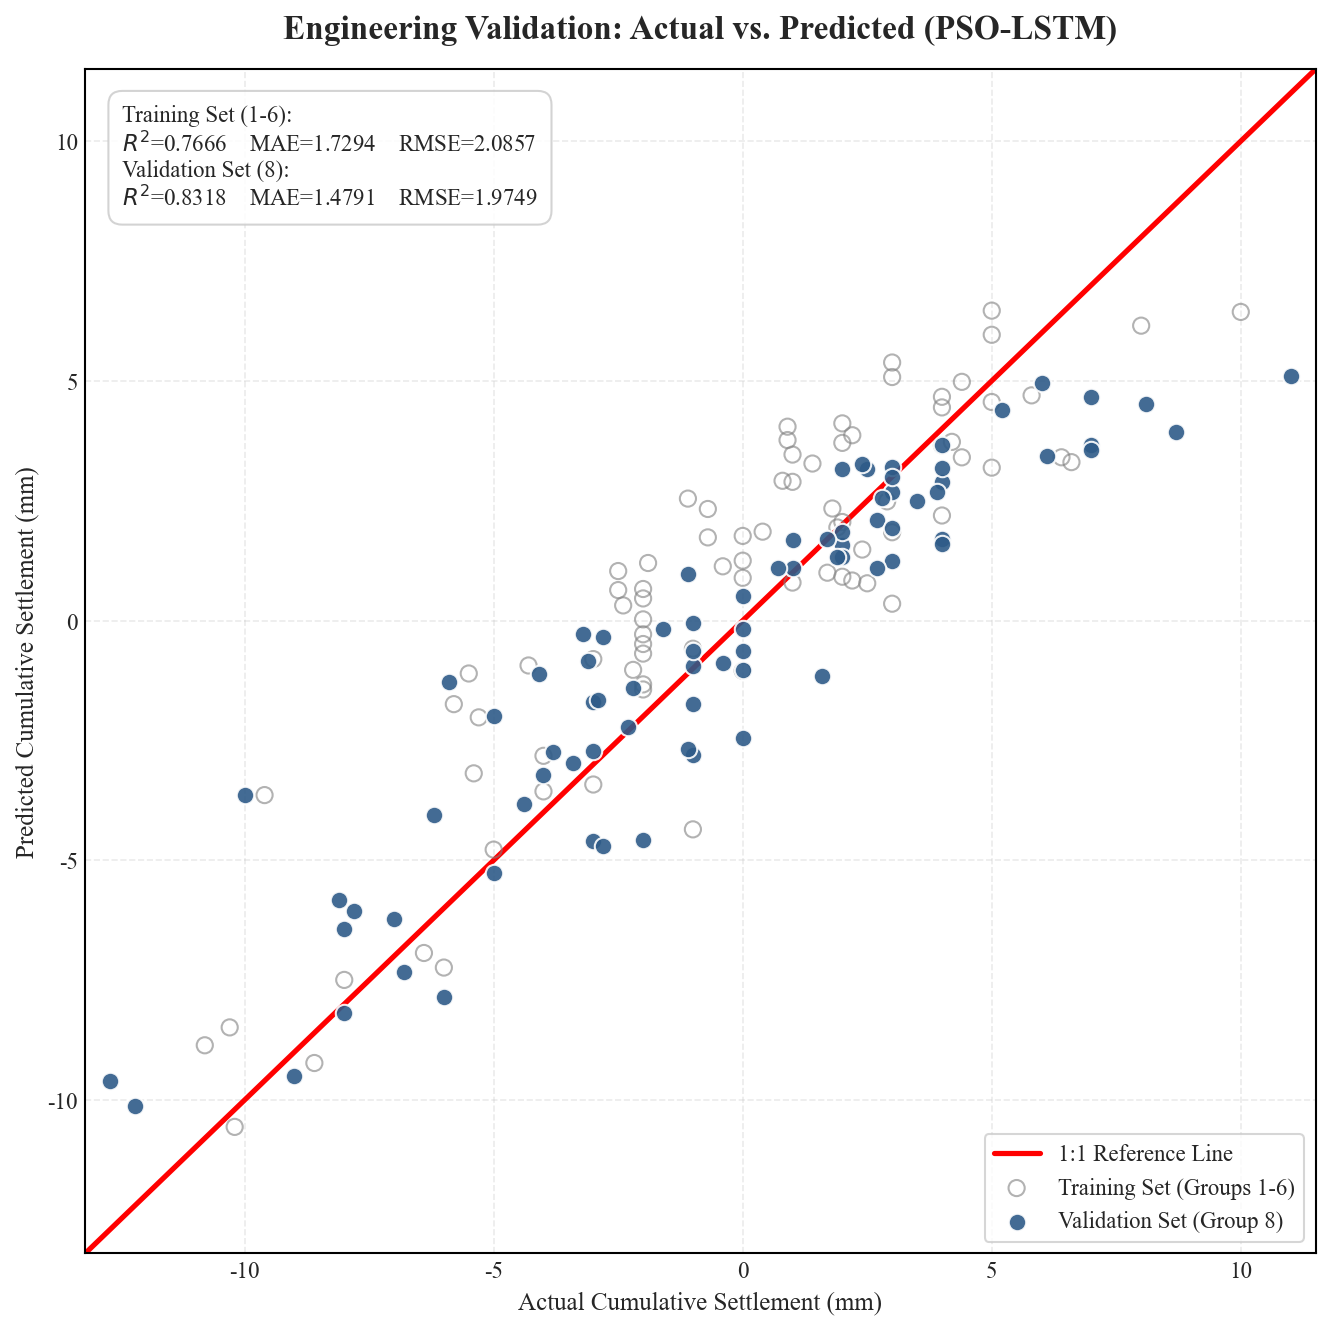

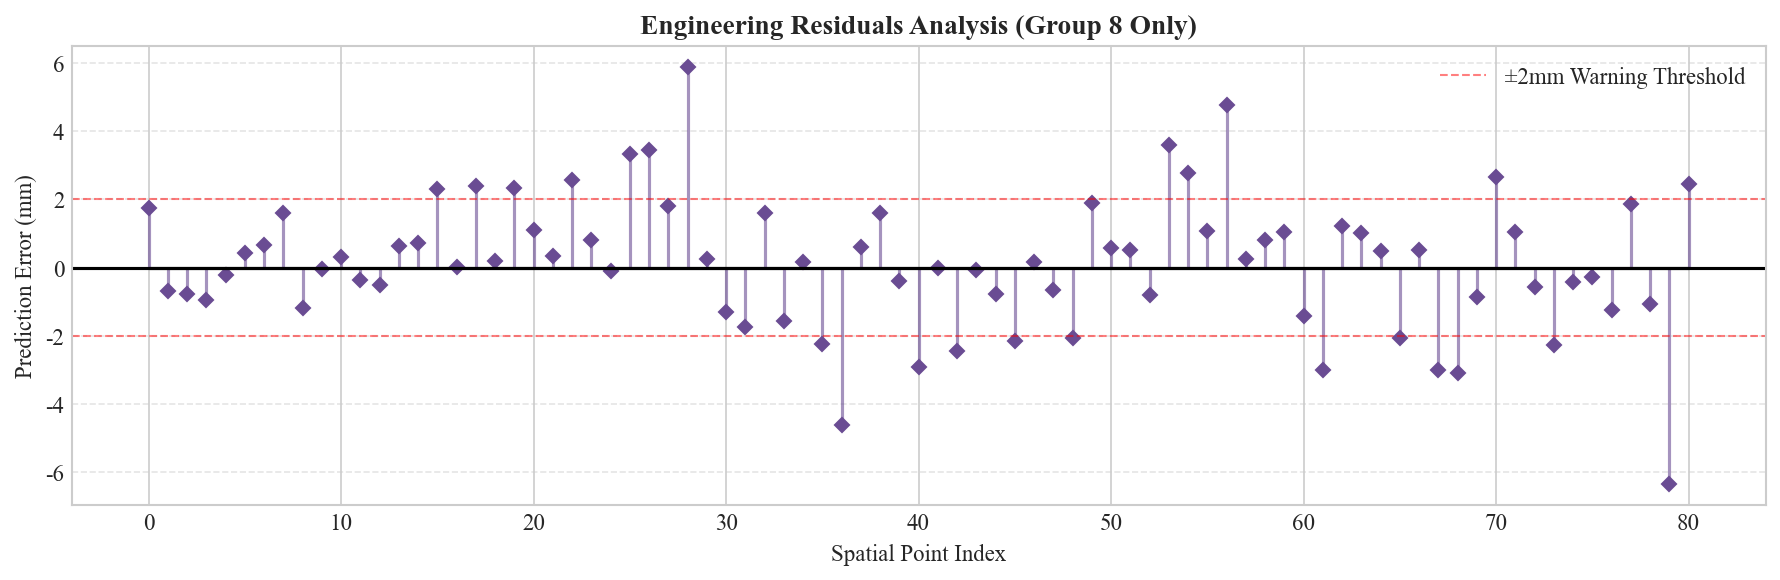

PSO-LSTM Execution Complete! (Results saved to 16.csv)


In [5]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import warnings


# 0.全局配置
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('bmh')

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'obs': '#2E5B88', 'pred': '#D64045', 'res': '#6A4C93'
}

def set_seed(seed=2024):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(2024)


# 保存函数
def universal_save_results(res_tr, res_te, res_va, model_code):
    """
    保存方法：
    1. 自动合并 6-1-1 划分的所有数据。
    2. 严格按原始索引排序（sort_index），确保 648 个点位顺序与原始 Excel 完全一致。
    """
    full_df = pd.concat([res_tr, res_te, res_va], axis=0)
    full_df = full_df.sort_index()
    
    output_df = pd.DataFrame({
        'Actual': full_df['Actual_Cum'], 
        'Pred': full_df['Pred_Cum']
    })
    
    file_name = f"{model_code}.csv" 
    output_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"\n数据已汇总并保存至: {file_name} | 总行数: {len(output_df)}\n")


# 1. 数据加载与预处理
file_path = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"
print("Loading data...")

try:
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    data_list = []
    for i, sheet in enumerate(all_sheets.values()):
        sheet.columns = [str(c).strip() for c in sheet.columns]
        col_map = {}
        for c in sheet.columns:
            if '编号' in c: col_map['ID'] = c
            elif '单次' in c: col_map['Single'] = c
            elif '速率' in c: col_map['Rate'] = c
            elif '累计' in c: col_map['Cumulative'] = c
        if len(col_map) >= 4:
            temp = sheet[[col_map['ID'], col_map['Single'], col_map['Rate'], col_map['Cumulative']]].copy()
            temp.columns = ['ID', 'Single', 'Rate', 'Cumulative']
            temp['TimeStep'] = i + 1
            data_list.append(temp)
    data = pd.concat(data_list).dropna().sort_values(['ID', 'TimeStep']).reset_index(drop=True)
except Exception as e:
    raise ValueError(f"无法读取数据，请检查路径: {e}")


# 2. 特征工程 
print("Engineering Features...")
df = data.copy()

df['Roll_Mean'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).mean())
df['Roll_Std'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).std())
df['EMA_3'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
df['Diff_1'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - x.shift(2))
df['Diff_2'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - 2*x.shift(2) + x.shift(3))

df = df.fillna(method='bfill').fillna(0)

feature_cols = ['Single', 'Rate', 'Cumulative', 'Roll_Mean', 'Roll_Std', 'EMA_3', 'Diff_1', 'Diff_2']
target_col = 'Cumulative'


# 3. 序列生成与【严格 6-1-1 划分】
scaler = MinMaxScaler(feature_range=(-1, 1))

train_subset = df[df['TimeStep'] <= 6]
scaler.fit(train_subset[feature_cols])

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.transform(df[feature_cols])

def create_sequences(dataframe, look_back):
    X, y, times, indices = [], [], [], []
    target_idx = feature_cols.index(target_col)
    for _, group in dataframe.groupby('ID'):
        group = group.sort_values('TimeStep')
        vals = group[feature_cols].values
        ts = group['TimeStep'].values
        idx = group.index.values 
        
        if len(vals) > look_back:
            for i in range(len(vals) - look_back):
                X.append(vals[i:i+look_back])
                y.append(vals[i+look_back, target_idx])
                times.append(ts[i+look_back])
                indices.append(idx[i+look_back])
    return np.array(X), np.array(y), np.array(times), np.array(indices)

look_back = 5 
X, y, times, indices = create_sequences(df_scaled, look_back)

mask_train = times <= 6
mask_test  = times == 7
mask_val   = times == 8

X_train, y_train_scaled = X[mask_train], y[mask_train]
X_test, y_test_scaled   = X[mask_test], y[mask_test]   
X_eval, y_eval_scaled   = X[mask_val], y[mask_val]     


# 4. PSO-LSTM 核心算法 (严格对照吴飞文献)
def build_lstm_model(units, learning_rate, input_shape):
    K.clear_session()
    model = Sequential()
    model.add(LSTM(int(units), return_sequences=True, input_shape=input_shape))
    model.add(Dropout(0.1))
    model.add(LSTM(int(units // 2))) 
    model.add(Dropout(0.1))
    model.add(Dense(1))
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    model.compile(loss='mse', optimizer=optimizer)
    return model

class PSO:
    def __init__(self, objective_func, bounds, n_particles=5, iterations=3):
        self.func = objective_func
        self.bounds = bounds
        self.n_particles = n_particles
        self.iterations = iterations
        self.particles = []
        self.gbest_score = float('inf')
        self.gbest_pos = None
        
        for _ in range(n_particles):
            pos = [random.uniform(b[0], b[1]) for b in bounds]
            self.particles.append({
                'pos': pos, 'vel': [0.0]*len(bounds),
                'pbest_pos': pos, 'pbest_score': float('inf')
            })
            
    def optimize(self):
        w, c1, c2 = 0.5, 1.5, 1.5
        print(f"Starting PSO Optimization (Using Group 7 for Fitness Evaluation)...")
        
        for t in range(self.iterations):
            for p in self.particles:
                score = self.func(p['pos'])
                if score < p['pbest_score']:
                    p['pbest_score'] = score
                    p['pbest_pos'] = p['pos']
                if score < self.gbest_score:
                    self.gbest_score = score
                    self.gbest_pos = p['pos']
            
            for p in self.particles:
                for j in range(len(self.bounds)):
                    r1, r2 = random.random(), random.random()
                    p['vel'][j] = w*p['vel'][j] + c1*r1*(p['pbest_pos'][j]-p['pos'][j]) + c2*r2*(self.gbest_pos[j]-p['pos'][j])
                    p['pos'][j] = np.clip(p['pos'][j] + p['vel'][j], self.bounds[j][0], self.bounds[j][1])
            
            print(f"  > Iter {t+1}/{self.iterations} | Best Loss (on Group 7): {self.gbest_score:.5f}")
        return self.gbest_pos

def fitness(params):
    units, lr = int(params[0]), params[1]
    model = build_lstm_model(units, lr, (look_back, len(feature_cols)))
    
    hist = model.fit(X_train, y_train_scaled, epochs=5, batch_size=8, verbose=0, validation_data=(X_test, y_test_scaled))
    return hist.history['val_loss'][-1]

pso = PSO(fitness, [(32, 160), (0.0001, 0.01)], n_particles=3, iterations=3)
best_params = pso.optimize()

print("\n" + "="*50)
print(f"PSO Optimization Completed!")
print(f"Best Units: {int(best_params[0])}")
print(f"Best LR: {best_params[1]:.6f}")
print("="*50 + "\n")


# 5. 训练最终模型 & 预测全量数据
final_units = int(best_params[0])
final_lr = best_params[1]

model = build_lstm_model(final_units, final_lr, (look_back, len(feature_cols)))

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("Training Final PSO-LSTM Model...")
history = model.fit(
    X_train, y_train_scaled,
    epochs=100, 
    batch_size=4,
    validation_data=(X_test, y_test_scaled), 
    callbacks=[early_stop],
    verbose=0
)


def inverse_transform_y(y_scaled, scaler, target_idx):
    dummy = np.zeros((len(y_scaled), len(feature_cols)))
    dummy[:, target_idx] = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

target_idx = feature_cols.index(target_col)


y_pred_train = inverse_transform_y(model.predict(X_train, verbose=0), scaler, target_idx)
y_true_train = inverse_transform_y(y_train_scaled, scaler, target_idx)

y_pred_test = inverse_transform_y(model.predict(X_test, verbose=0), scaler, target_idx)
y_true_test = inverse_transform_y(y_test_scaled, scaler, target_idx)

y_pred_eval = inverse_transform_y(model.predict(X_eval, verbose=0), scaler, target_idx)
y_true_eval = inverse_transform_y(y_eval_scaled, scaler, target_idx)
residuals_eval = y_true_eval - y_pred_eval

train_r2 = r2_score(y_true_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
train_mae = mean_absolute_error(y_true_train, y_pred_train)

eval_r2 = r2_score(y_true_eval, y_pred_eval)
eval_rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
eval_mae = mean_absolute_error(y_true_eval, y_pred_eval)

print("\n" + "="*50)
print(f"【PSO-LSTM Engineering Validation Results】")
print(f"【Training Set (Groups 1-6)】 R²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"【Engineering Validation Set (Group 8)】 R²: {eval_r2:.4f}, RMSE: {eval_rmse:.2f}")
print("="*50)

res_tr = pd.DataFrame({'Actual_Cum': y_true_train, 'Pred_Cum': y_pred_train}, index=indices[mask_train])
res_te = pd.DataFrame({'Actual_Cum': y_true_test, 'Pred_Cum': y_pred_test}, index=indices[mask_test])
res_va = pd.DataFrame({'Actual_Cum': y_true_eval, 'Pred_Cum': y_pred_eval}, index=indices[mask_val])

universal_save_results(res_tr, res_te, res_va, '16')


# 6. 绘图
print("Generating Engineering Validation Charts...")

# --- Chart 1: 1:1 Regression Plot  ---
plt.figure(figsize=(9, 9), dpi=150)
ax = plt.gca() 

limit_min = min(y_true_train.min(), y_pred_train.min(), y_true_eval.min(), y_pred_eval.min()) - 0.5
limit_max = max(y_true_train.max(), y_pred_train.max(), y_true_eval.max(), y_pred_eval.max()) + 0.5

plt.plot([limit_min, limit_max], [limit_min, limit_max], 'r-', linewidth=2.5, label='1:1 Reference Line', zorder=1)

plt.scatter(y_true_train, y_pred_train, facecolors='none', edgecolors='gray', 
            marker='o', s=60, alpha=0.6, label='Training Set (Groups 1-6)', zorder=2)
plt.scatter(y_true_eval, y_pred_eval, color=COLORS['obs'], edgecolor='white', 
            marker='o', s=70, alpha=0.9, label='Validation Set (Group 8)', zorder=3)

line1 = "Training Set (1-6):"
line2 = f"$R^2$={train_r2:.4f}    MAE={train_mae:.4f}    RMSE={train_rmse:.4f}"
line3 = "Validation Set (8):"
line4 = f"$R^2$={eval_r2:.4f}    MAE={eval_mae:.4f}    RMSE={eval_rmse:.4f}"

full_info = f"{line1}\n{line2}\n{line3}\n{line4}"

plt.text(0.03, 0.97, full_info, transform=ax.transAxes, fontsize=11, verticalalignment='top',
         family='Times New Roman', bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.85, edgecolor='#CCCCCC'))

plt.xlabel('Actual Cumulative Settlement (mm)', fontsize=12)
plt.ylabel('Predicted Cumulative Settlement (mm)', fontsize=12)
plt.title('Engineering Validation: Actual vs. Predicted (PSO-LSTM)', fontweight='bold', fontsize=16, pad=15)

plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)

for spine_name in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine_name].set_visible(True)     
    ax.spines[spine_name].set_color('black')    
    ax.spines[spine_name].set_linewidth(1.0)    

plt.tight_layout()
plt.show()

# --- Chart 2: Residual Analysis (仅展示工程验证第 8 组) ---
plt.figure(figsize=(12, 4), dpi=150)
x_axis = range(len(y_true_eval))
plt.stem(x_axis, residuals_eval, linefmt=COLORS['res'], markerfmt='D', basefmt='k-')
plt.setp(plt.gca().get_children()[0], linewidth=1.5, alpha=0.6)
plt.setp(plt.gca().get_children()[1], markersize=5, color=COLORS['res'])
plt.axhline(0, color='black', linestyle='-', linewidth=1.5)

plt.axhline(2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='±2mm Warning Threshold') 
plt.axhline(-2, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.title('Engineering Residuals Analysis (Group 8 Only)', fontweight='bold')
plt.xlabel('Spatial Point Index')
plt.ylabel('Prediction Error (mm)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("PSO-LSTM Execution Complete! (Results saved to 16.csv)")

Loading data...
Engineering Features...
Training CNN-GRU Model (Ref: Tang Haoran, 2024)...

【CNN-GRU Engineering Validation Results】
【Training Set (Group 1-6)】 R²: 0.9034, RMSE: 1.34
【Engineering Validation Set (Group 8)】 R²: 0.8200, RMSE: 2.04

数据已汇总并保存至: 17.csv | 总行数: 243

Generating Engineering Validation Charts...


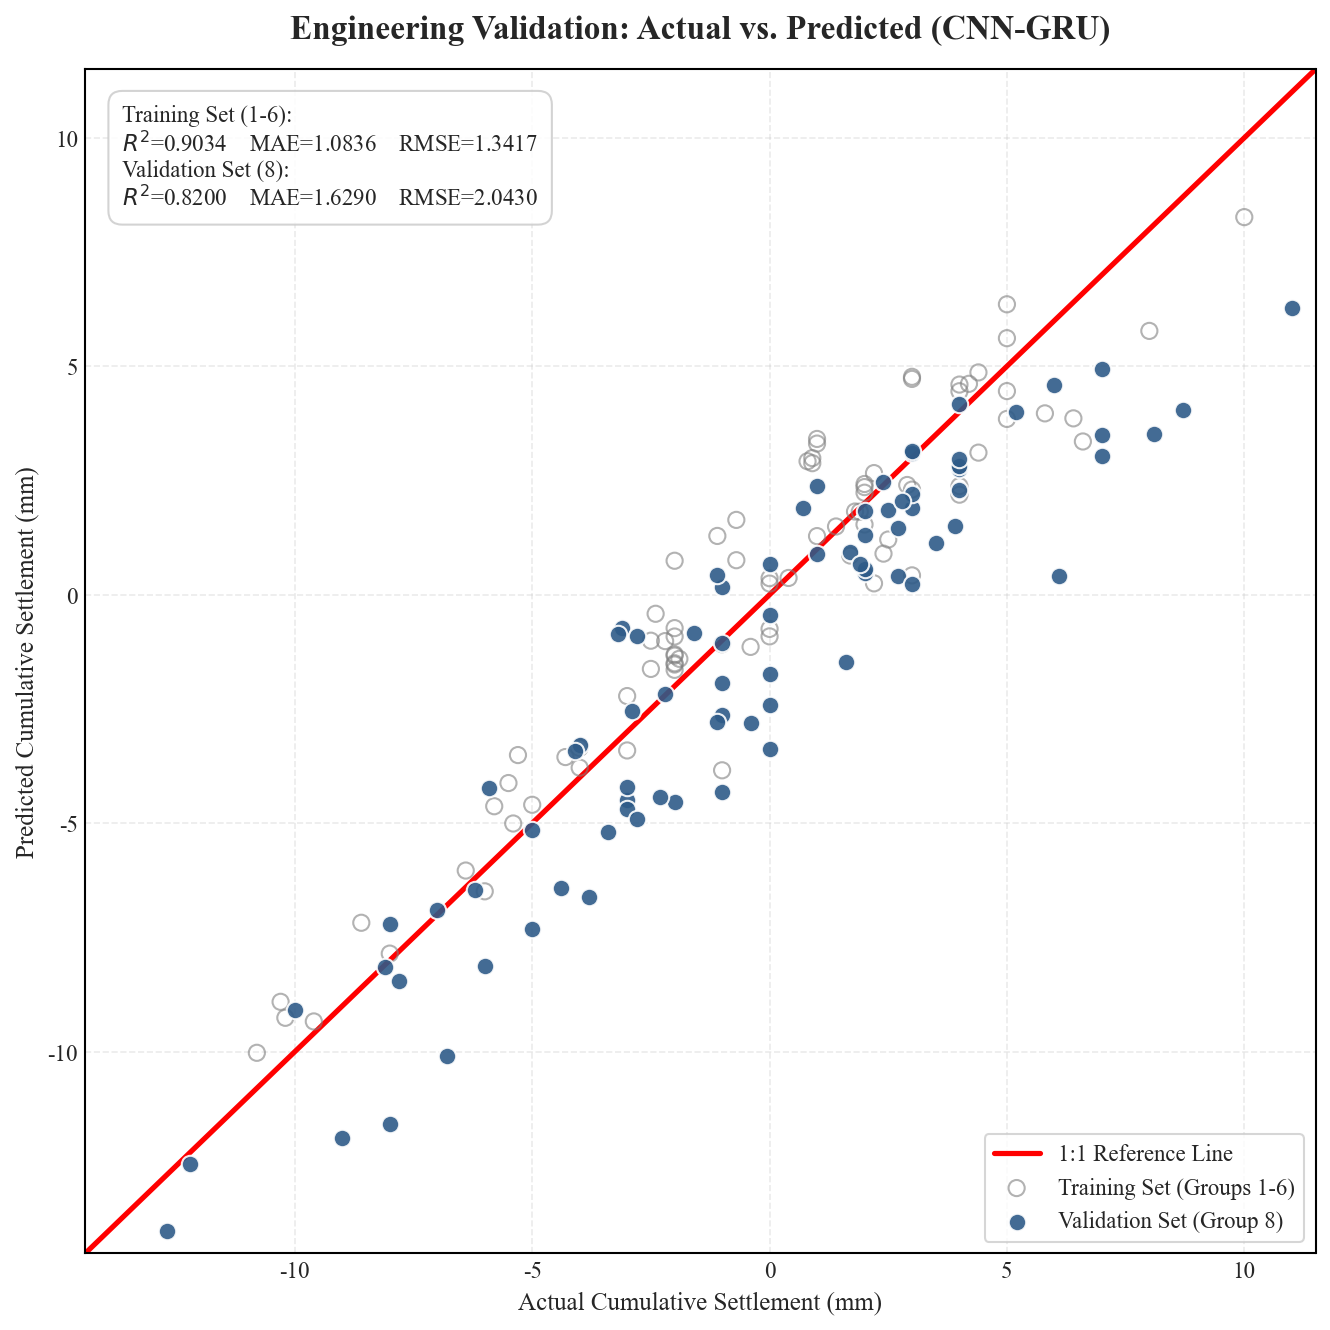

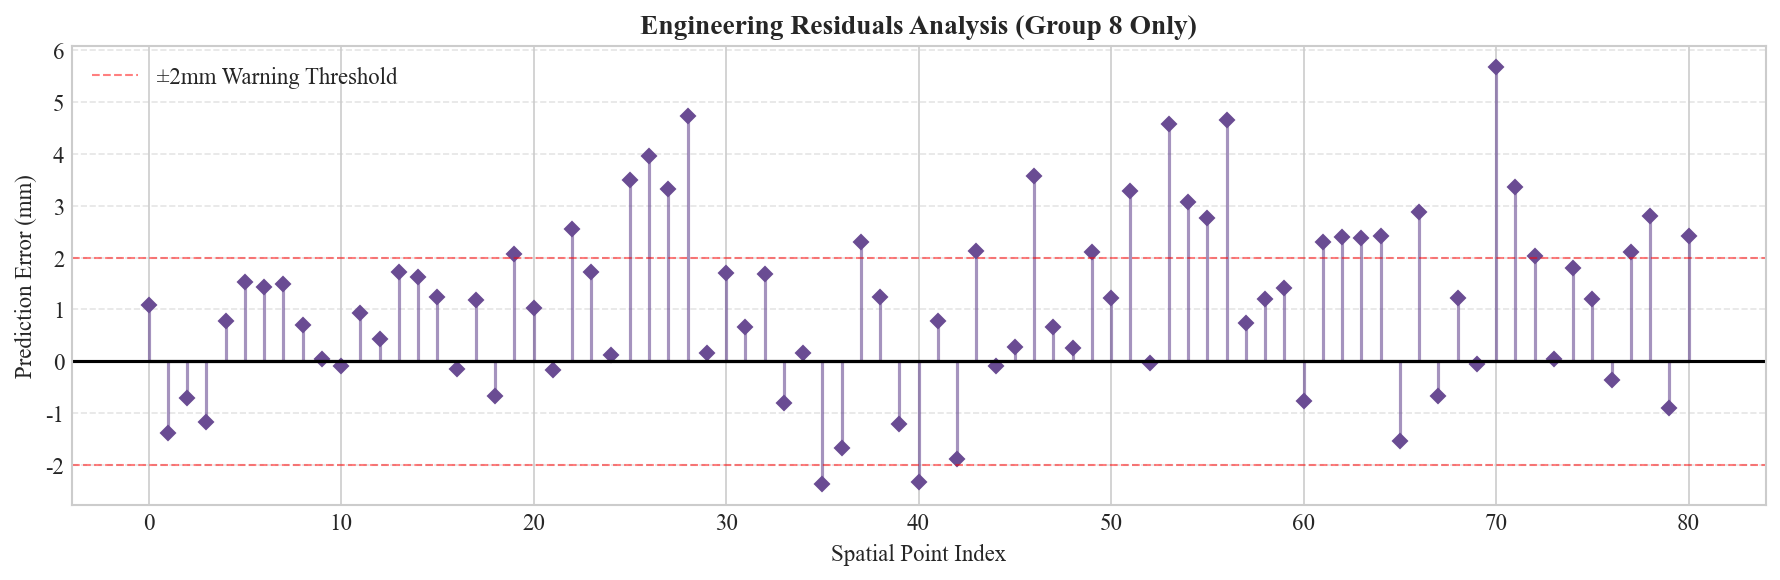

CNN-GRU Engineering Validation Execution Complete! (Results saved to 17.csv)


In [6]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, Conv1D, MaxPooling1D, Flatten
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import warnings


# 0. 全局配置
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('bmh')

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'obs': '#2E5B88', 'pred': '#D64045', 'res': '#6A4C93'
}

def set_seed(seed=2024):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(2024)


# 保存函数 
def universal_save_results(res_tr, res_te, res_va, model_code):
    """
    保存方法：
    1. 自动合并 6-1-1 划分的所有数据。
    2. 严格按原始索引排序（sort_index），确保 648 个点位顺序与原始 Excel 完全一致。
    """
    full_df = pd.concat([res_tr, res_te, res_va], axis=0)
    full_df = full_df.sort_index()
    
    output_df = pd.DataFrame({
        'Actual': full_df['Actual_Cum'], 
        'Pred': full_df['Pred_Cum']
    })
    
    file_name = f"{model_code}.csv" 
    output_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"\n数据已汇总并保存至: {file_name} | 总行数: {len(output_df)}\n")

    
# 1. 数据加载与预处理
file_path = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"
print("Loading data...")

try:
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    data_list = []
    for i, sheet in enumerate(all_sheets.values()):
        sheet.columns = [str(c).strip() for c in sheet.columns]
        col_map = {}
        for c in sheet.columns:
            if '编号' in c: col_map['ID'] = c
            elif '单次' in c: col_map['Single'] = c
            elif '速率' in c: col_map['Rate'] = c
            elif '累计' in c: col_map['Cumulative'] = c
        if len(col_map) >= 4:
            temp = sheet[[col_map['ID'], col_map['Single'], col_map['Rate'], col_map['Cumulative']]].copy()
            temp.columns = ['ID', 'Single', 'Rate', 'Cumulative']
            temp['TimeStep'] = i + 1
            data_list.append(temp)
    data = pd.concat(data_list).dropna().sort_values(['ID', 'TimeStep']).reset_index(drop=True)
except Exception as e:
    raise ValueError(f"无法读取数据，请检查路径: {e}")


# 2. 特征工程 
print("Engineering Features...")
df = data.copy()

df['Roll_Mean'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).mean())
df['Roll_Std'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).rolling(3).std())
df['EMA_3'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1).ewm(span=3, adjust=False).mean())
df['Diff_1'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - x.shift(2))
df['Diff_2'] = df.groupby('ID')['Single'].transform(lambda x: x.shift(1) - 2*x.shift(2) + x.shift(3))

df = df.fillna(method='bfill').fillna(0)

feature_cols = ['Single', 'Rate', 'Cumulative', 'Roll_Mean', 'Roll_Std', 'EMA_3', 'Diff_1', 'Diff_2']
target_col = 'Cumulative'


# 3. 序列生成与【严格 6-1-1 划分】
scaler = MinMaxScaler(feature_range=(-1, 1))

train_subset = df[df['TimeStep'] <= 6]
scaler.fit(train_subset[feature_cols])

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.transform(df[feature_cols])

def create_sequences(dataframe, look_back):
    X, y, times, indices = [], [], [], []
    target_idx = feature_cols.index(target_col)
    for _, group in dataframe.groupby('ID'):
        group = group.sort_values('TimeStep')
        vals = group[feature_cols].values
        ts = group['TimeStep'].values
        idx = group.index.values 
        
        if len(vals) > look_back:
            for i in range(len(vals) - look_back):
                X.append(vals[i:i+look_back])
                y.append(vals[i+look_back, target_idx])
                times.append(ts[i+look_back])
                indices.append(idx[i+look_back])
    return np.array(X), np.array(y), np.array(times), np.array(indices)

look_back = 5 
X, y, times, indices = create_sequences(df_scaled, look_back)


mask_train = times <= 6
mask_test  = times == 7
mask_eval  = times == 8

X_train, y_train_scaled = X[mask_train], y[mask_train]
X_test, y_test_scaled   = X[mask_test], y[mask_test]   
X_eval, y_eval_scaled   = X[mask_eval], y[mask_eval]   


# 4. CNN-GRU 混合模型 (严格复刻唐浩然文献思路)
def build_cnn_gru_model(input_shape):
    K.clear_session()
    model = Sequential()
    
    model.add(Conv1D(filters=64, kernel_size=2, activation='relu', input_shape=input_shape, padding='same'))
    
    model.add(MaxPooling1D(pool_size=2)) 
    model.add(Dropout(0.1))
    
    model.add(GRU(128, return_sequences=True))
    model.add(Dropout(0.1))
    model.add(GRU(64, return_sequences=False))
    model.add(Dropout(0.1))
    
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1)) 
    
    optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
    model.compile(loss='mse', optimizer=optimizer)
    return model

print("Training CNN-GRU Model (Ref: Tang Haoran, 2024)...")
model = build_cnn_gru_model((look_back, len(feature_cols)))

early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train, y_train_scaled,
    epochs=150,
    batch_size=4,
    validation_data=(X_test, y_test_scaled), # 监控第7组
    callbacks=[early_stop],
    verbose=0
)


# 5. 预测与评估 
def inverse_transform_y(y_scaled, scaler, target_idx):
    dummy = np.zeros((len(y_scaled), len(feature_cols)))
    dummy[:, target_idx] = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

target_idx = feature_cols.index(target_col)

y_pred_train = inverse_transform_y(model.predict(X_train, verbose=0), scaler, target_idx)
y_true_train = inverse_transform_y(y_train_scaled, scaler, target_idx)

y_pred_test = inverse_transform_y(model.predict(X_test, verbose=0), scaler, target_idx)
y_true_test = inverse_transform_y(y_test_scaled, scaler, target_idx)

y_pred_eval = inverse_transform_y(model.predict(X_eval, verbose=0), scaler, target_idx)
y_true_eval = inverse_transform_y(y_eval_scaled, scaler, target_idx)
residuals_eval = y_true_eval - y_pred_eval

train_r2 = r2_score(y_true_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
train_mae = mean_absolute_error(y_true_train, y_pred_train)

eval_r2 = r2_score(y_true_eval, y_pred_eval)
eval_rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
eval_mae = mean_absolute_error(y_true_eval, y_pred_eval)

print("\n" + "="*50)
print(f"【CNN-GRU Engineering Validation Results】")
print(f"【Training Set (Group 1-6)】 R²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"【Engineering Validation Set (Group 8)】 R²: {eval_r2:.4f}, RMSE: {eval_rmse:.2f}")
print("="*50)

res_tr = pd.DataFrame({'Actual_Cum': y_true_train, 'Pred_Cum': y_pred_train}, index=indices[mask_train])
res_te = pd.DataFrame({'Actual_Cum': y_true_test, 'Pred_Cum': y_pred_test}, index=indices[mask_test])
res_va = pd.DataFrame({'Actual_Cum': y_true_eval, 'Pred_Cum': y_pred_eval}, index=indices[mask_eval])

universal_save_results(res_tr, res_te, res_va, '17')


# 6. 绘图 

print("Generating Engineering Validation Charts...")

# --- Chart 1: 1:1 Regression Plot  ---
plt.figure(figsize=(9, 9), dpi=150)
ax = plt.gca() 

limit_min = min(y_true_train.min(), y_pred_train.min(), y_true_eval.min(), y_pred_eval.min()) - 0.5
limit_max = max(y_true_train.max(), y_pred_train.max(), y_true_eval.max(), y_pred_eval.max()) + 0.5

plt.plot([limit_min, limit_max], [limit_min, limit_max], 'r-', linewidth=2.5, label='1:1 Reference Line', zorder=1)

plt.scatter(y_true_train, y_pred_train, facecolors='none', edgecolors='gray', 
            marker='o', s=60, alpha=0.6, label='Training Set (Groups 1-6)', zorder=2)
plt.scatter(y_true_eval, y_pred_eval, color=COLORS['obs'], edgecolor='white', 
            marker='o', s=70, alpha=0.9, label='Validation Set (Group 8)', zorder=3)

line1 = "Training Set (1-6):"
line2 = f"$R^2$={train_r2:.4f}    MAE={train_mae:.4f}    RMSE={train_rmse:.4f}"
line3 = "Validation Set (8):"
line4 = f"$R^2$={eval_r2:.4f}    MAE={eval_mae:.4f}    RMSE={eval_rmse:.4f}"

full_info = f"{line1}\n{line2}\n{line3}\n{line4}"

plt.text(0.03, 0.97, full_info, transform=ax.transAxes, fontsize=11, verticalalignment='top',
         family='Times New Roman', bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.85, edgecolor='#CCCCCC'))

plt.xlabel('Actual Cumulative Settlement (mm)', fontsize=12)
plt.ylabel('Predicted Cumulative Settlement (mm)', fontsize=12)
plt.title('Engineering Validation: Actual vs. Predicted (CNN-GRU)', fontweight='bold', fontsize=16, pad=15)

plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)

for spine_name in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine_name].set_visible(True)     
    ax.spines[spine_name].set_color('black')    
    ax.spines[spine_name].set_linewidth(1.0)    

plt.tight_layout()
plt.show()

# --- Chart 2: Residual Analysis (仅展示工程验证第 8 组) ---
plt.figure(figsize=(12, 4), dpi=150)
x_axis = range(len(y_true_eval))
plt.stem(x_axis, residuals_eval, linefmt=COLORS['res'], markerfmt='D', basefmt='k-')
plt.setp(plt.gca().get_children()[0], linewidth=1.5, alpha=0.6)
plt.setp(plt.gca().get_children()[1], markersize=5, color=COLORS['res'])
plt.axhline(0, color='black', linestyle='-', linewidth=1.5)

plt.axhline(2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='±2mm Warning Threshold') 
plt.axhline(-2, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.title('Engineering Residuals Analysis (Group 8 Only)', fontweight='bold')
plt.xlabel('Spatial Point Index')
plt.ylabel('Prediction Error (mm)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("CNN-GRU Engineering Validation Execution Complete! (Results saved to 17.csv)")

 Loading data...
 Applying Akima Interpolation & Engineering Features...
 Training Bi-LSTM Model (Ref: Chen Weihang, 2022)...

【Bi-LSTM Engineering Validation Results】
【Training Set (Group 1-6)】 R²: 0.8771, RMSE: 1.51
【Engineering Validation Set (Group 8)】 R²: 0.8884, RMSE: 1.61

 数据已汇总并保存至: 18.csv | 总行数: 243

 Generating Engineering Validation Charts...


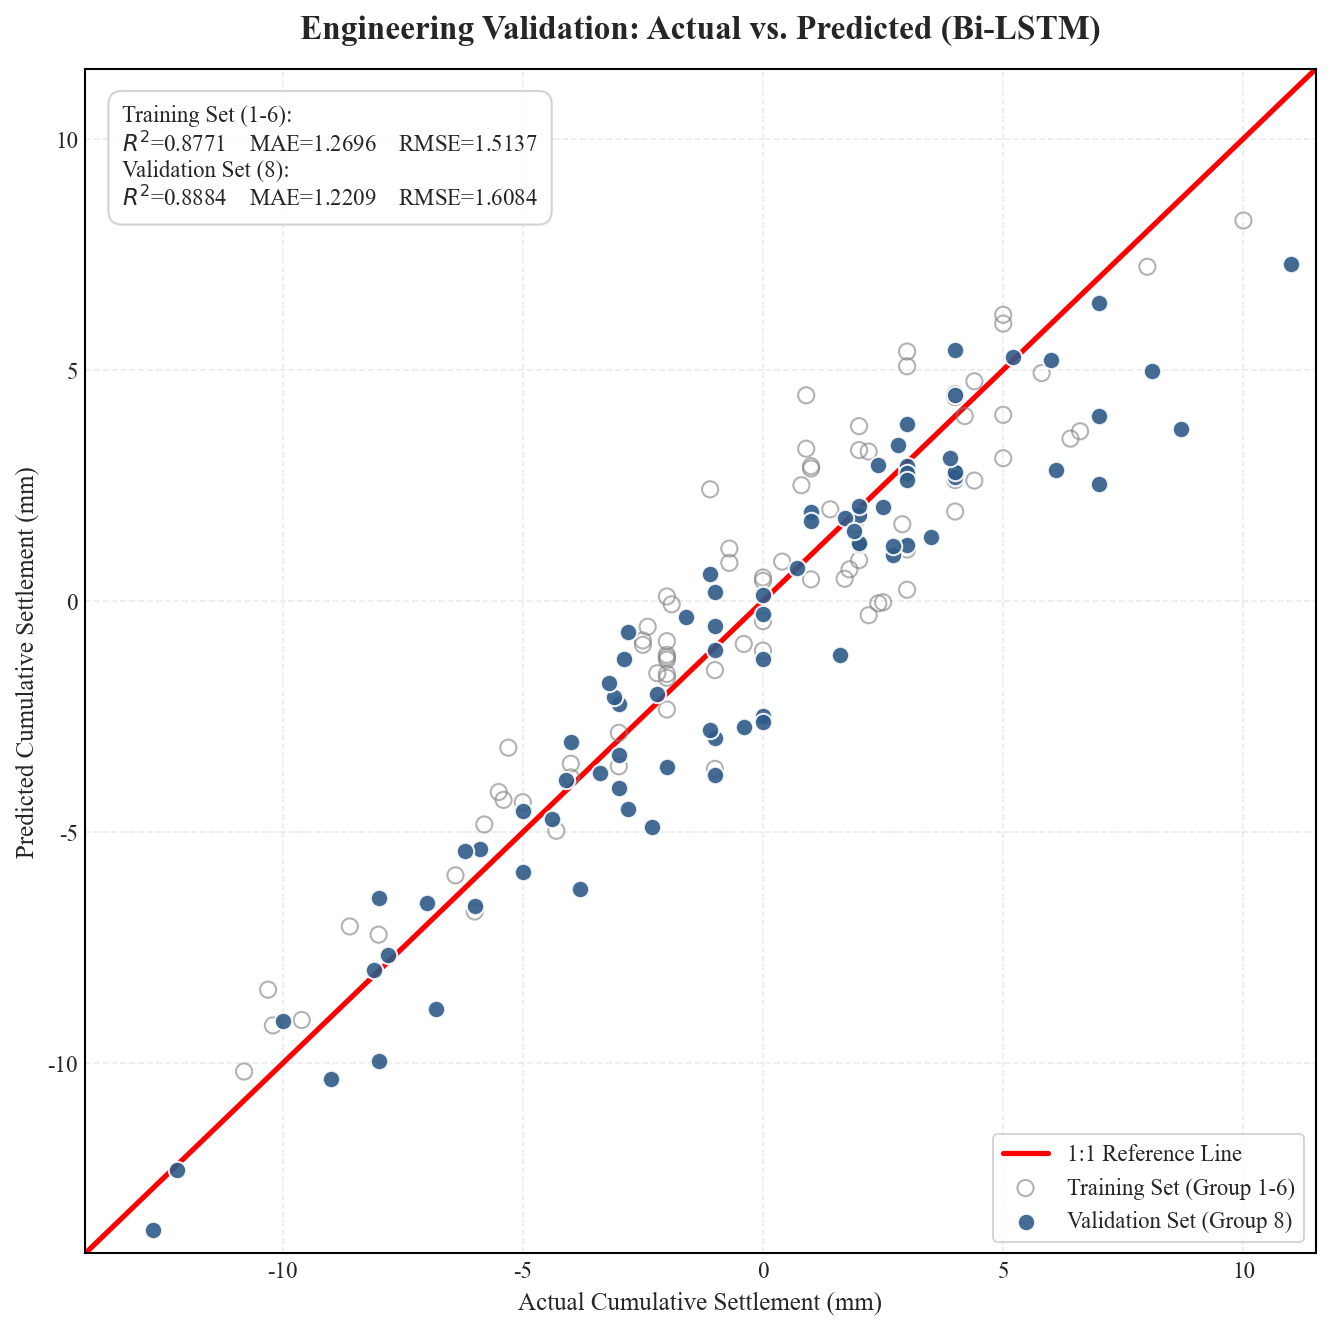

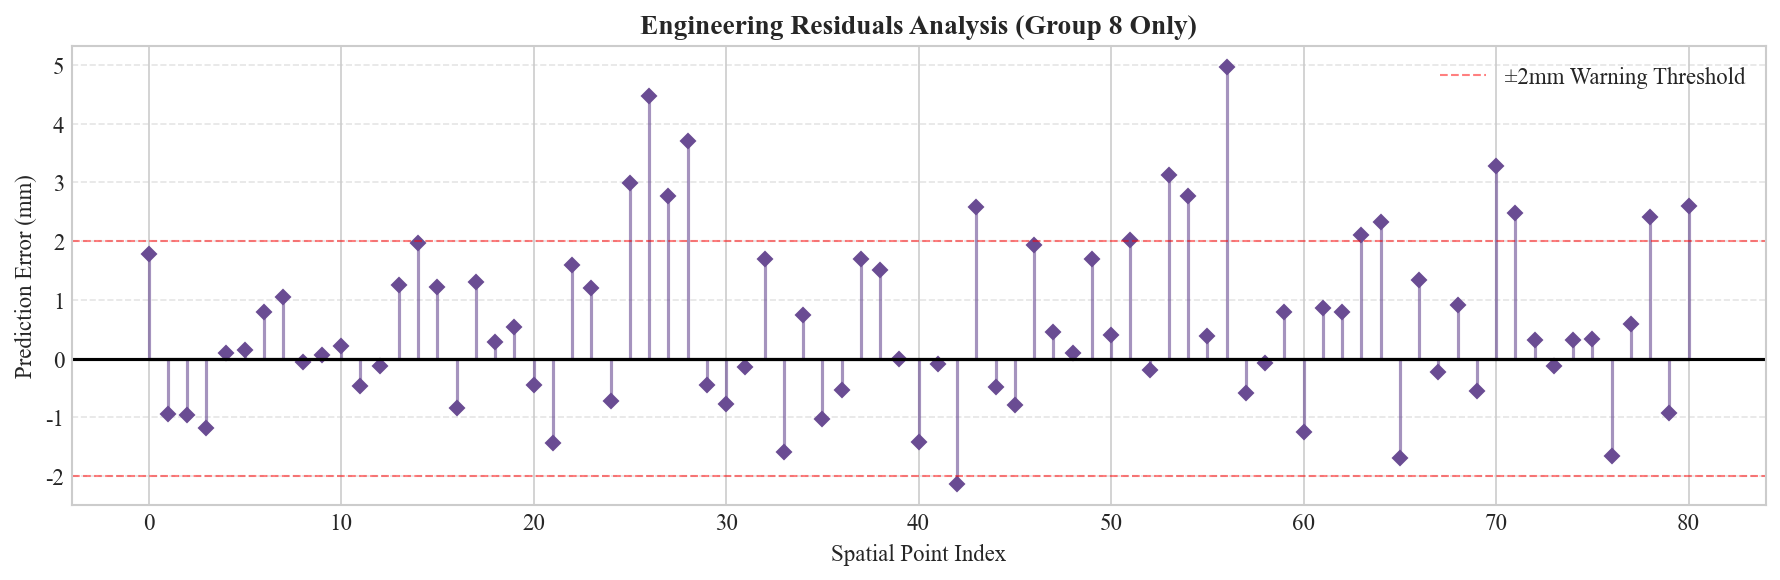

 Bi-LSTM Engineering Validation Execution Complete! (Results saved to 18.csv)


In [7]:
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os
import matplotlib.pyplot as plt
from scipy.interpolate import Akima1DInterpolator
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
import warnings


# 0. 全局配置 
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings('ignore')

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    plt.style.use('bmh')

plt.rcParams['font.family'] = ['Times New Roman', 'SimSun']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

COLORS = {
    'obs': '#2E5B88', 'pred': '#D64045', 'fit': '#E9C46A', 
    'res': '#6A4C93', 'train_edge': '#555555', 'train_face': 'white'
}

def set_seed(seed=2024):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(2024)


# 保存函数 
def universal_save_results(res_tr, res_te, res_va, model_code):
    """
    万能保存方法：
    1. 自动合并 6-1-1 划分的所有数据。
    2. 严格按原始索引排序（sort_index），确保点位顺序与原始 Excel 完全一致。
    """
    full_df = pd.concat([res_tr, res_te, res_va], axis=0)
    full_df = full_df.sort_index()
    
    output_df = pd.DataFrame({
        'Actual': full_df['Actual_Cum'], 
        'Pred': full_df['Pred_Cum']
    })
    
    file_name = f"{model_code}.csv" 
    output_df.to_csv(file_name, index=False, encoding='utf-8-sig')
    print(f"\n 数据已汇总并保存至: {file_name} | 总行数: {len(output_df)}\n")



# 1. 数据加载与预处理
file_path = r"C:\Users\姚怡帆\Desktop\数据集\沉降数据(1).xlsx"
print(" Loading data...")

try:
    all_sheets = pd.read_excel(file_path, sheet_name=None)
    data_list = []
    for i, sheet in enumerate(all_sheets.values()):
        sheet.columns = [str(c).strip() for c in sheet.columns]
        col_map = {}
        for c in sheet.columns:
            if '编号' in c: col_map['ID'] = c
            elif '单次' in c: col_map['Single'] = c
            elif '速率' in c: col_map['Rate'] = c
            elif '累计' in c: col_map['Cumulative'] = c
        if len(col_map) >= 4:
            temp = sheet[[col_map['ID'], col_map['Single'], col_map['Rate'], col_map['Cumulative']]].copy()
            temp.columns = ['ID', 'Single', 'Rate', 'Cumulative']
            temp['TimeStep'] = i + 1
            data_list.append(temp)
    data = pd.concat(data_list).dropna().sort_values(['ID', 'TimeStep']).reset_index(drop=True)
except Exception as e:
    raise ValueError(f" 无法读取数据，请检查路径: {e}")


# 2. Akima 插值与特征工程
print(" Applying Akima Interpolation & Engineering Features...")

def apply_akima_and_features(group):
    x = group['TimeStep'].values
    y = group['Cumulative'].values
    if len(x) > 3: 
        try:
            akima = Akima1DInterpolator(x, y)
            group['Cumulative_Akima'] = akima(x) 
        except:
            group['Cumulative_Akima'] = y
    else:
        group['Cumulative_Akima'] = y
    return group

data = data.groupby('ID', group_keys=False).apply(apply_akima_and_features).reset_index(drop=True)
df = data.copy()
target_col = 'Cumulative_Akima' 

df['Roll_Mean'] = df.groupby('ID')[target_col].transform(lambda x: x.shift(1).rolling(3).mean())
df['Roll_Std'] = df.groupby('ID')[target_col].transform(lambda x: x.shift(1).rolling(3).std())
df['Diff_1'] = df.groupby('ID')[target_col].transform(lambda x: x.shift(1) - x.shift(2))
df['Diff_2'] = df.groupby('ID')[target_col].transform(lambda x: x.shift(1) - 2*x.shift(2) + x.shift(3))
df = df.fillna(method='bfill').fillna(0)

feature_cols = ['Single', 'Rate', 'Cumulative_Akima', 'Roll_Mean', 'Roll_Std', 'Diff_1', 'Diff_2']


# 3. 序列生成与【严格 6-1-1 划分】
scaler = MinMaxScaler(feature_range=(-1, 1))

train_subset = df[df['TimeStep'] <= 6]
scaler.fit(train_subset[feature_cols])

df_scaled = df.copy()
df_scaled[feature_cols] = scaler.transform(df[feature_cols])

def create_sequences(dataframe, look_back):
    X, y, times, indices = [], [], [], []
    target_idx = feature_cols.index(target_col)
    for _, group in dataframe.groupby('ID'):
        group = group.sort_values('TimeStep')
        vals = group[feature_cols].values
        ts = group['TimeStep'].values
        idx = group.index.values 
        
        if len(vals) > look_back:
            for i in range(len(vals) - look_back):
                X.append(vals[i:i+look_back])
                y.append(vals[i+look_back, target_idx])
                times.append(ts[i+look_back])
                indices.append(idx[i+look_back])
    return np.array(X), np.array(y), np.array(times), np.array(indices)

look_back = 5 
X, y, times, indices = create_sequences(df_scaled, look_back)

mask_train = times <= 6
mask_test  = times == 7
mask_eval  = times == 8

X_train, y_train_scaled = X[mask_train], y[mask_train]
X_test, y_test_scaled   = X[mask_test], y[mask_test]   
X_eval, y_eval_scaled   = X[mask_eval], y[mask_eval]   


# 4. Bi-LSTM 模型构建
def build_bi_lstm_model(input_shape):
    K.clear_session()
    model = Sequential()
    model.add(Bidirectional(LSTM(128, return_sequences=True), input_shape=input_shape))
    model.add(Dropout(0.1))
    model.add(Bidirectional(LSTM(64, return_sequences=False)))
    model.add(Dropout(0.1))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1))
    
    optimizer = tf.keras.optimizers.Nadam(learning_rate=0.001)
    model.compile(loss='mse', optimizer=optimizer)
    return model

print(" Training Bi-LSTM Model (Ref: Chen Weihang, 2022)...")
model = build_bi_lstm_model((look_back, len(feature_cols)))


early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

history = model.fit(
    X_train, y_train_scaled,
    epochs=150,
    batch_size=4,
    validation_data=(X_test, y_test_scaled), 
    callbacks=[early_stop],
    verbose=0
)


# 5. 预测与反归一化
def inverse_transform_y(y_scaled, scaler, target_idx):
    dummy = np.zeros((len(y_scaled), len(feature_cols)))
    dummy[:, target_idx] = y_scaled.flatten()
    return scaler.inverse_transform(dummy)[:, target_idx]

target_idx = feature_cols.index(target_col)

y_pred_train = inverse_transform_y(model.predict(X_train, verbose=0), scaler, target_idx)
y_true_train = inverse_transform_y(y_train_scaled, scaler, target_idx)

y_pred_test = inverse_transform_y(model.predict(X_test, verbose=0), scaler, target_idx)
y_true_test = inverse_transform_y(y_test_scaled, scaler, target_idx)

y_pred_eval = inverse_transform_y(model.predict(X_eval, verbose=0), scaler, target_idx)
y_true_eval = inverse_transform_y(y_eval_scaled, scaler, target_idx)
residuals_eval = y_true_eval - y_pred_eval

train_r2 = r2_score(y_true_train, y_pred_train)
train_rmse = np.sqrt(mean_squared_error(y_true_train, y_pred_train))
train_mae = mean_absolute_error(y_true_train, y_pred_train)

eval_r2 = r2_score(y_true_eval, y_pred_eval)
eval_rmse = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval))
eval_mae = mean_absolute_error(y_true_eval, y_pred_eval)

print("\n" + "="*50)
print(f"【Bi-LSTM Engineering Validation Results】")
print(f"【Training Set (Group 1-6)】 R²: {train_r2:.4f}, RMSE: {train_rmse:.2f}")
print(f"【Engineering Validation Set (Group 8)】 R²: {eval_r2:.4f}, RMSE: {eval_rmse:.2f}")
print("="*50)

res_tr = pd.DataFrame({'Actual_Cum': y_true_train, 'Pred_Cum': y_pred_train}, index=indices[mask_train])
res_te = pd.DataFrame({'Actual_Cum': y_true_test, 'Pred_Cum': y_pred_test}, index=indices[mask_test])
res_va = pd.DataFrame({'Actual_Cum': y_true_eval, 'Pred_Cum': y_pred_eval}, index=indices[mask_eval])

universal_save_results(res_tr, res_te, res_va, '18')


# 6. 工程验证专属绘图
print(" Generating Engineering Validation Charts...")

# --- Chart 1: 1:1 Regression Plot ---
plt.figure(figsize=(9, 9), dpi=150)
ax = plt.gca() 

limit_min = min(y_true_train.min(), y_pred_train.min(), y_true_eval.min(), y_pred_eval.min()) - 0.5
limit_max = max(y_true_train.max(), y_pred_train.max(), y_true_eval.max(), y_pred_eval.max()) + 0.5

plt.plot([limit_min, limit_max], [limit_min, limit_max], 'r-', linewidth=2.5, label='1:1 Reference Line', zorder=1)

plt.scatter(y_true_train, y_pred_train, facecolors='none', edgecolors='gray', 
            marker='o', s=60, alpha=0.6, label='Training Set (Group 1-6)', zorder=2)
plt.scatter(y_true_eval, y_pred_eval, color=COLORS['obs'], edgecolor='white', 
            marker='o', s=70, alpha=0.9, label='Validation Set (Group 8)', zorder=3)

line1 = "Training Set (1-6):"
line2 = f"$R^2$={train_r2:.4f}    MAE={train_mae:.4f}    RMSE={train_rmse:.4f}"
line3 = "Validation Set (8):"
line4 = f"$R^2$={eval_r2:.4f}    MAE={eval_mae:.4f}    RMSE={eval_rmse:.4f}"

full_info = f"{line1}\n{line2}\n{line3}\n{line4}"

plt.text(0.03, 0.97, full_info, transform=ax.transAxes, fontsize=11, verticalalignment='top',
         family='Times New Roman', bbox=dict(boxstyle='round,pad=0.6', facecolor='white', alpha=0.85, edgecolor='#CCCCCC'))

plt.xlabel('Actual Cumulative Settlement (mm)', fontsize=12)
plt.ylabel('Predicted Cumulative Settlement (mm)', fontsize=12)
plt.title('Engineering Validation: Actual vs. Predicted (Bi-LSTM)', fontweight='bold', fontsize=16, pad=15)

plt.legend(loc='lower right', frameon=True, fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.xlim(limit_min, limit_max)
plt.ylim(limit_min, limit_max)

for spine_name in ['top', 'bottom', 'left', 'right']:
    ax.spines[spine_name].set_visible(True)     
    ax.spines[spine_name].set_color('black')    
    ax.spines[spine_name].set_linewidth(1.0)    

plt.tight_layout()
plt.show()

# --- Chart 2: Residual Analysis (仅针对工程验证第 8 组) ---
plt.figure(figsize=(12, 4), dpi=150)
x_axis = range(len(y_true_eval))
plt.stem(x_axis, residuals_eval, linefmt=COLORS['res'], markerfmt='D', basefmt='k-')
plt.setp(plt.gca().get_children()[0], linewidth=1.5, alpha=0.6)
plt.setp(plt.gca().get_children()[1], markersize=5, color=COLORS['res'])
plt.axhline(0, color='black', linestyle='-', linewidth=1.5)
plt.axhline(2, color='red', linestyle='--', linewidth=1, alpha=0.5, label='±2mm Warning Threshold') # 添加工程警告线
plt.axhline(-2, color='red', linestyle='--', linewidth=1, alpha=0.5)

plt.title('Engineering Residuals Analysis (Group 8 Only)', fontweight='bold')
plt.xlabel('Spatial Point Index')
plt.ylabel('Prediction Error (mm)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(" Bi-LSTM Engineering Validation Execution Complete! (Results saved to 18.csv)")